**Section 0 - SET KAGGLE TOKENT**

In [ ]:
!mkdir -p ~/.kaggle && echo "<your-kaggle-token>" > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

print("Kaggle access token has been set. Please re-run the data download cell above.")

Kaggle access token has been set. Please re-run the data download cell above.


**Section 1 - Dataset loading, inspection and split**

In [ ]:
# Load libraries, download the Kaggle dataset, create output folders, and load training.csv

from pathlib import Path
import zipfile
import random
from datetime import datetime

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

OUTPUT_DIR = Path("outputs")
PLOTS_DIR = OUTPUT_DIR / "plots"
MODELS_DIR = OUTPUT_DIR / "models"
RESULTS_DIR = OUTPUT_DIR / "results"

for folder in [OUTPUT_DIR, PLOTS_DIR, MODELS_DIR, RESULTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

path = kagglehub.competition_download("facial-keypoints-detection")
DATA_DIR = Path(path)

print("Path to competition files:", DATA_DIR)

for zip_path in DATA_DIR.glob("*.zip"):
    extract_dir = DATA_DIR / zip_path.stem

    if not extract_dir.exists():
        extract_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_dir)
        print(f"Extracted: {zip_path.name} -> {extract_dir}")
    else:
        print(f"Already extracted: {zip_path.name}")

training_files = list(DATA_DIR.rglob("training.csv"))

if len(training_files) == 0:
    raise FileNotFoundError("training.csv was not found.")

TRAIN_CSV_PATH = training_files[0]
df = pd.read_csv(TRAIN_CSV_PATH)

KEYPOINT_COLUMNS = [col for col in df.columns if col != "Image"]

print("Using device:", DEVICE)
print("Training CSV path:", TRAIN_CSV_PATH)
print("Dataset shape:", df.shape)
display(df.head())

100%|██████████| 76.3M/76.3M [00:00<00:00, 146MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/facial-keypoints-detection
Extracted: test.zip -> /root/.cache/kagglehub/competitions/facial-keypoints-detection/test
Extracted: training.zip -> /root/.cache/kagglehub/competitions/facial-keypoints-detection/training
Using device: cuda
Training CSV path: /root/.cache/kagglehub/competitions/facial-keypoints-detection/training/training.csv
Dataset shape: (7049, 31)


,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,Image
0,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,57.066803,61.195308,79.970165,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,238 236 237 238 240 240 239 241 241 243 240 23...
1,64.332936,34.970077,29.949277,33.448715,58.856170,35.274349,70.722723,36.187166,36.034723,34.361532,...,55.660936,56.421447,76.352000,35.122383,76.047660,46.684596,70.266553,45.467915,85.480170,219 215 204 196 204 211 212 200 180 168 178 19...
2,65.057053,34.909642,30.903789,34.909642,59.412000,36.320968,70.984421,36.320968,37.678105,36.320968,...,53.538947,60.822947,73.014316,33.726316,72.732000,47.274947,70.191789,47.274947,78.659368,144 142 159 180 188 188 184 180 167 132 84 59 ...
3,65.225739,37.261774,32.023096,37.261774,60.003339,39.127179,72.314713,38.380967,37.618643,38.754115,...,54.166539,65.598887,72.703722,37.245496,74.195478,50.303165,70.091687,51.561183,78.268383,193 192 193 194 194 194 193 192 168 111 50 12 ...
4,66.725301,39.621261,32.244810,38.042032,58.565890,39.621261,72.515926,39.884466,36.982380,39.094852,...,64.889521,60.671411,77.523239,31.191755,76.997301,44.962748,73.707387,44.227141,86.871166,147 148 160 196 215 214 216 217 219 220 206 18...


Number of samples: 7049
Number of columns: 31
Number of keypoint coordinates: 30
Number of facial keypoints: 15


,missing_count,missing_percentage
left_eyebrow_outer_end_y,4824,68.435239
left_eyebrow_outer_end_x,4824,68.435239
right_eyebrow_outer_end_x,4813,68.279189
right_eyebrow_outer_end_y,4813,68.279189
left_eye_outer_corner_y,4782,67.839410
left_eye_outer_corner_x,4782,67.839410
right_eye_inner_corner_y,4781,67.825223
right_eye_inner_corner_x,4781,67.825223
right_eye_outer_corner_y,4781,67.825223
right_eye_outer_corner_x,4781,67.825223


Missing values summary saved at: outputs/results/missing_values_summary.csv
Complete samples: 2140
Incomplete samples: 4909
Complete samples percentage: 30.36 %


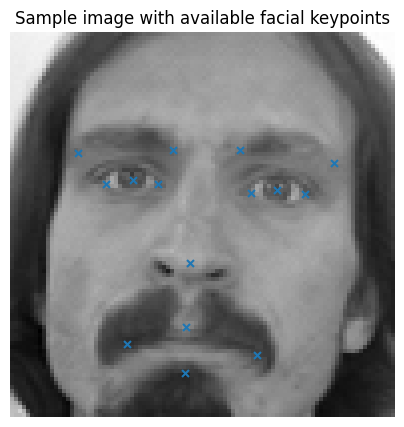

,split,total_samples,complete_samples,incomplete_samples,complete_percentage,incomplete_percentage
0,full_dataset,7049,2140,4909,30.358916,69.641084
1,train,5639,1712,3927,30.359993,69.640007
2,validation,1410,428,982,30.354610,69.645390


Train shape: (5639, 32)
Validation shape: (1410, 32)
Split summary saved at: outputs/results/split_completeness_summary.csv


In [ ]:
# Inspect dataset characteristics, save missing-value summaries, and create a stratified train-validation split

def image_string_to_array(image_string):
    image = np.fromstring(image_string, sep=" ", dtype=np.float32)
    image = image.reshape(96, 96)
    return image


def plot_image_with_keypoints(row, save_path=None):
    image = image_string_to_array(row["Image"])
    keypoints = row[KEYPOINT_COLUMNS].values.astype(np.float32).reshape(-1, 2)
    valid_keypoints = ~np.isnan(keypoints).any(axis=1)

    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap="gray")
    plt.scatter(
        keypoints[valid_keypoints, 0],
        keypoints[valid_keypoints, 1],
        s=25,
        marker="x"
    )
    plt.title("Sample image with available facial keypoints")
    plt.axis("off")

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)

    plt.show()


print("Number of samples:", len(df))
print("Number of columns:", len(df.columns))
print("Number of keypoint coordinates:", len(KEYPOINT_COLUMNS))
print("Number of facial keypoints:", len(KEYPOINT_COLUMNS) // 2)

missing_values = df[KEYPOINT_COLUMNS].isna().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percentage": missing_percentage
}).sort_values("missing_percentage", ascending=False)

display(missing_summary)

missing_summary.to_csv(RESULTS_DIR / "missing_values_summary.csv")
print("Missing values summary saved at:", RESULTS_DIR / "missing_values_summary.csv")

complete_rows = df[KEYPOINT_COLUMNS].notna().all(axis=1).sum()
incomplete_rows = len(df) - complete_rows

print("Complete samples:", complete_rows)
print("Incomplete samples:", incomplete_rows)
print("Complete samples percentage:", round((complete_rows / len(df)) * 100, 2), "%")

plot_image_with_keypoints(
    df.iloc[0],
    save_path=PLOTS_DIR / "sample_image_keypoints.png"
)

df["is_complete"] = df[KEYPOINT_COLUMNS].notna().all(axis=1).astype(int)

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["is_complete"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

KEYPOINT_COLUMNS = [col for col in df.columns if col not in ["Image", "is_complete"]]

def summarize_split_completeness(dataframe, split_name):
    complete_count = dataframe["is_complete"].sum()
    incomplete_count = len(dataframe) - complete_count
    complete_percentage = complete_count / len(dataframe) * 100
    incomplete_percentage = incomplete_count / len(dataframe) * 100

    return {
        "split": split_name,
        "total_samples": len(dataframe),
        "complete_samples": complete_count,
        "incomplete_samples": incomplete_count,
        "complete_percentage": complete_percentage,
        "incomplete_percentage": incomplete_percentage
    }

split_summary = pd.DataFrame([
    summarize_split_completeness(df, "full_dataset"),
    summarize_split_completeness(train_df, "train"),
    summarize_split_completeness(val_df, "validation")
])

display(split_summary)

split_summary.to_csv(
    RESULTS_DIR / "split_completeness_summary.csv",
    index=False
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Split summary saved at:", RESULTS_DIR / "split_completeness_summary.csv")

**Section 2 - Baseline Model**

Baseline RMSE: 3.9078 pixels
Baseline MAE:  2.6483 pixels
Baseline NME:  0.1169


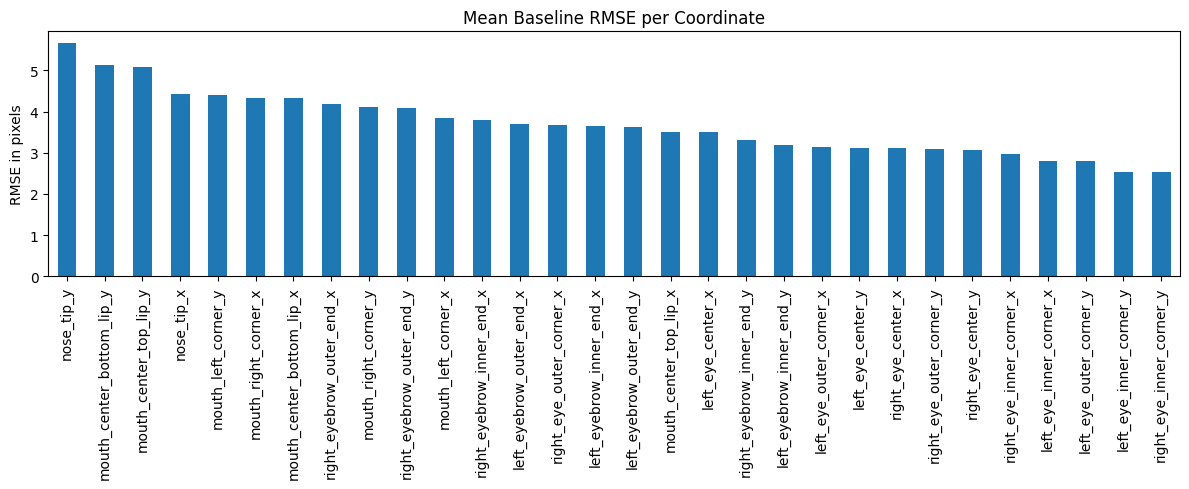

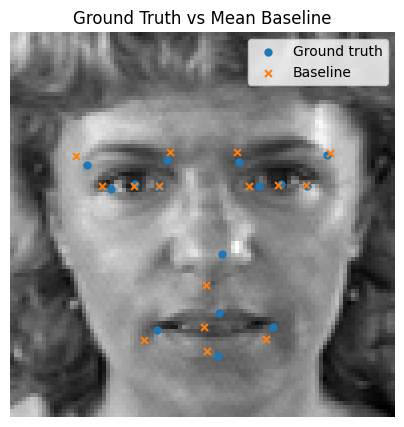

In [ ]:
# Build, evaluate, plot, and save the mean keypoint baseline using RMSE, MAE and NME

def rmse_ignore_nan(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    mask = ~np.isnan(y_true)
    mse = np.mean((y_true[mask] - y_pred[mask]) ** 2)
    return np.sqrt(mse)


def mae_ignore_nan(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    mask = ~np.isnan(y_true)
    mae = np.mean(np.abs(y_true[mask] - y_pred[mask]))
    return mae


def nme_ignore_nan(y_true_df, y_pred_df, keypoint_columns):
    y_true = y_true_df[keypoint_columns].values.astype(np.float32)
    y_pred = y_pred_df[keypoint_columns].values.astype(np.float32)

    true_points = y_true.reshape(-1, 15, 2)
    pred_points = y_pred.reshape(-1, 15, 2)
    valid_points = ~np.isnan(true_points).any(axis=2)

    left_eye_idx = keypoint_columns.index("left_eye_center_x") // 2
    right_eye_idx = keypoint_columns.index("right_eye_center_x") // 2

    left_eye_valid = valid_points[:, left_eye_idx]
    right_eye_valid = valid_points[:, right_eye_idx]
    valid_normalizer = left_eye_valid & right_eye_valid

    interocular_distance = np.sqrt(
        np.sum(
            (true_points[:, left_eye_idx, :] - true_points[:, right_eye_idx, :]) ** 2,
            axis=1
        )
    )

    valid_normalizer = valid_normalizer & (interocular_distance > 1e-6)

    distances = np.sqrt(np.sum((pred_points - true_points) ** 2, axis=2))
    valid_for_nme = valid_points & valid_normalizer[:, None]

    if valid_for_nme.sum() == 0:
        return np.nan

    normalized_errors = distances[valid_for_nme] / np.repeat(
        interocular_distance[:, None],
        repeats=15,
        axis=1
    )[valid_for_nme]

    return np.mean(normalized_errors)


def rmse_per_coordinate_ignore_nan(y_true_df, y_pred_df):
    coordinate_rmse = {}

    for col in y_true_df.columns:
        y_true_col = y_true_df[col].values.astype(np.float32)
        y_pred_col = y_pred_df[col].values.astype(np.float32)
        mask = ~np.isnan(y_true_col)
        coordinate_rmse[col] = np.sqrt(np.mean((y_true_col[mask] - y_pred_col[mask]) ** 2))

    return pd.Series(coordinate_rmse).sort_values(ascending=False)


def plot_true_vs_baseline(row, prediction_row, save_path=None):
    image = image_string_to_array(row["Image"])

    true_keypoints = row[KEYPOINT_COLUMNS].values.astype(np.float32).reshape(-1, 2)
    pred_keypoints = prediction_row[KEYPOINT_COLUMNS].values.astype(np.float32).reshape(-1, 2)

    true_valid = ~np.isnan(true_keypoints).any(axis=1)

    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap="gray")
    plt.scatter(
        true_keypoints[true_valid, 0],
        true_keypoints[true_valid, 1],
        s=25,
        marker="o",
        label="Ground truth"
    )
    plt.scatter(
        pred_keypoints[:, 0],
        pred_keypoints[:, 1],
        s=25,
        marker="x",
        label="Baseline"
    )
    plt.title("Ground Truth vs Mean Baseline")
    plt.legend()
    plt.axis("off")

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)

    plt.show()


y_train = train_df[KEYPOINT_COLUMNS]
y_val = val_df[KEYPOINT_COLUMNS]

mean_keypoints = y_train.mean(axis=0, skipna=True)

baseline_val_predictions = pd.DataFrame(
    np.tile(mean_keypoints.values, (len(val_df), 1)),
    columns=KEYPOINT_COLUMNS,
    index=val_df.index
)

baseline_rmse = rmse_ignore_nan(y_val, baseline_val_predictions)
baseline_mae = mae_ignore_nan(y_val, baseline_val_predictions)
baseline_nme = nme_ignore_nan(y_val, baseline_val_predictions, KEYPOINT_COLUMNS)

baseline_rmse_per_coordinate = rmse_per_coordinate_ignore_nan(
    y_val,
    baseline_val_predictions
)

print(f"Baseline RMSE: {baseline_rmse:.4f} pixels")
print(f"Baseline MAE:  {baseline_mae:.4f} pixels")
print(f"Baseline NME:  {baseline_nme:.4f}")

baseline_results = pd.DataFrame([{
    "model": "mean_keypoint_baseline",
    "architecture": "constant_mean_prediction",
    "optimizer": "none",
    "loss": "none",
    "rmse": baseline_rmse,
    "mae": baseline_mae,
    "normalized_mean_error": baseline_nme,
    "experiment_name": np.nan
}])

baseline_results.to_csv(
    RESULTS_DIR / "baseline_results.csv",
    index=False
)

baseline_rmse_per_coordinate.to_csv(
    RESULTS_DIR / "baseline_rmse_per_coordinate.csv",
    header=["rmse"]
)

experiment_results = baseline_results.copy()
experiment_results.to_csv(
    RESULTS_DIR / "experiment_results.csv",
    index=False
)

plt.figure(figsize=(12, 5))
baseline_rmse_per_coordinate.plot(kind="bar")
plt.ylabel("RMSE in pixels")
plt.title("Mean Baseline RMSE per Coordinate")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "baseline_rmse_per_coordinate.png", dpi=150)
plt.show()

complete_val_indices = val_df.index[val_df["is_complete"] == 1].tolist()
sample_index = complete_val_indices[0]

plot_true_vs_baseline(
    val_df.loc[sample_index],
    baseline_val_predictions.loc[sample_index],
    save_path=PLOTS_DIR / "baseline_true_vs_prediction.png"
)

**Section 3 - Shared data, training and evaluation utilities**

In [ ]:
# Define reusable datasets, photometric augmentation, and train-validation-test dataloaders

MLP_TEST_SIZE = 0.15

train_model_df, test_model_df = train_test_split(
    train_df,
    test_size=MLP_TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=train_df["is_complete"]
)

train_model_df = train_model_df.reset_index(drop=True)
val_model_df = val_df.reset_index(drop=True)
test_model_df = test_model_df.reset_index(drop=True)

target_fill_values = train_model_df[KEYPOINT_COLUMNS].mean(axis=0, skipna=True)

print("Model train shape:", train_model_df.shape)
print("Model validation shape:", val_model_df.shape)
print("Model internal test shape:", test_model_df.shape)


def apply_brightness(image, brightness_range=(0.75, 1.25)):
    factor = random.uniform(*brightness_range)
    image = image * factor
    image = np.clip(image, 0.0, 1.0)
    return image


def apply_contrast(image, contrast_range=(0.75, 1.25)):
    factor = random.uniform(*contrast_range)
    mean = image.mean()
    image = (image - mean) * factor + mean
    image = np.clip(image, 0.0, 1.0)
    return image


def apply_gaussian_noise(image, noise_std_range=(0.0, 0.05)):
    std = random.uniform(*noise_std_range)
    noise = np.random.normal(loc=0.0, scale=std, size=image.shape)
    image = image + noise
    image = np.clip(image, 0.0, 1.0)
    return image.astype(np.float32)


def apply_photometric_augmentation(
    image,
    brightness_range=(0.75, 1.25),
    contrast_range=(0.75, 1.25),
    noise_std_range=(0.0, 0.05),
    p_brightness=0.7,
    p_contrast=0.7,
    p_noise=0.5
):
    augmented_image = image.copy()

    if random.random() < p_brightness:
        augmented_image = apply_brightness(
            augmented_image,
            brightness_range=brightness_range
        )

    if random.random() < p_contrast:
        augmented_image = apply_contrast(
            augmented_image,
            contrast_range=contrast_range
        )

    if random.random() < p_noise:
        augmented_image = apply_gaussian_noise(
            augmented_image,
            noise_std_range=noise_std_range
        )

    return augmented_image.astype(np.float32)


photometric_augmentation_config = {
    "brightness_range": (0.75, 1.25),
    "contrast_range": (0.75, 1.25),
    "noise_std_range": (0.0, 0.05),
    "p_brightness": 0.7,
    "p_contrast": 0.7,
    "p_noise": 0.5
}


class FacialKeypointsDataset(Dataset):
    def __init__(
        self,
        dataframe,
        keypoint_columns,
        target_fill_values,
        image_mode="flat",
        augment=False,
        augmentation_config=None
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.keypoint_columns = keypoint_columns
        self.target_fill_values = target_fill_values
        self.image_mode = image_mode
        self.augment = augment
        self.augmentation_config = augmentation_config if augmentation_config is not None else {}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = image_string_to_array(row["Image"])
        image = image / 255.0
        image = image.astype(np.float32)

        if self.augment:
            image = apply_photometric_augmentation(
                image,
                brightness_range=self.augmentation_config.get("brightness_range", (0.75, 1.25)),
                contrast_range=self.augmentation_config.get("contrast_range", (0.75, 1.25)),
                noise_std_range=self.augmentation_config.get("noise_std_range", (0.0, 0.05)),
                p_brightness=self.augmentation_config.get("p_brightness", 0.7),
                p_contrast=self.augmentation_config.get("p_contrast", 0.7),
                p_noise=self.augmentation_config.get("p_noise", 0.5)
            )

        if self.image_mode == "flat":
            image = image.reshape(-1)
        elif self.image_mode == "cnn":
            image = np.expand_dims(image, axis=0)
        else:
            raise ValueError(f"Unsupported image_mode: {self.image_mode}")

        target = row[self.keypoint_columns].values.astype(np.float32)
        mask = ~np.isnan(target)
        mask = mask.astype(np.float32)

        filled_target = pd.Series(target, index=self.keypoint_columns)
        filled_target = filled_target.fillna(self.target_fill_values).values.astype(np.float32)
        filled_target = filled_target / 96.0

        return {
            "image": torch.tensor(image, dtype=torch.float32),
            "target": torch.tensor(filled_target, dtype=torch.float32),
            "mask": torch.tensor(mask, dtype=torch.float32)
        }


def create_dataloaders(image_mode="flat", batch_size=64, augment_train=False):
    train_dataset = FacialKeypointsDataset(
        dataframe=train_model_df,
        keypoint_columns=KEYPOINT_COLUMNS,
        target_fill_values=target_fill_values,
        image_mode=image_mode,
        augment=augment_train,
        augmentation_config=photometric_augmentation_config
    )

    val_dataset = FacialKeypointsDataset(
        dataframe=val_model_df,
        keypoint_columns=KEYPOINT_COLUMNS,
        target_fill_values=target_fill_values,
        image_mode=image_mode,
        augment=False
    )

    test_dataset = FacialKeypointsDataset(
        dataframe=test_model_df,
        keypoint_columns=KEYPOINT_COLUMNS,
        target_fill_values=target_fill_values,
        image_mode=image_mode,
        augment=False
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


train_mlp_loader, val_mlp_loader, test_mlp_loader = create_dataloaders(
    image_mode="flat",
    batch_size=64,
    augment_train=False
)

train_cnn_loader, val_cnn_loader, test_cnn_loader = create_dataloaders(
    image_mode="cnn",
    batch_size=64,
    augment_train=False
)

sample_mlp_batch = next(iter(train_mlp_loader))
sample_cnn_batch = next(iter(train_cnn_loader))

print("Sample MLP input shape:", sample_mlp_batch["image"].shape)
print("Sample CNN input shape:", sample_cnn_batch["image"].shape)
print("Sample target shape:", sample_cnn_batch["target"].shape)


Model train shape: (4793, 32)
Model validation shape: (1410, 32)
Model internal test shape: (846, 32)
Sample MLP input shape: torch.Size([64, 9216])
Sample CNN input shape: torch.Size([64, 1, 96, 96])
Sample target shape: torch.Size([64, 30])


In [ ]:
# Define reusable losses, optimizers, metrics, training functions, plotting, and experiment execution using NME

def get_loss_function(loss_name):
    if loss_name == "masked_mse":
        return nn.MSELoss(reduction="none")
    elif loss_name == "masked_l1":
        return nn.L1Loss(reduction="none")
    elif loss_name == "masked_smooth_l1":
        return nn.SmoothL1Loss(reduction="none")
    else:
        raise ValueError(f"Unsupported loss function: {loss_name}")


def compute_masked_loss(predictions, targets, masks, loss_fn):
    raw_loss = loss_fn(predictions, targets)
    masked_loss = raw_loss * masks
    return masked_loss.sum() / masks.sum().clamp(min=1.0)


def get_optimizer(optimizer_name, model, learning_rate, weight_decay=0.0):
    if optimizer_name == "adam":
        return torch.optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
    elif optimizer_name == "sgd":
        return torch.optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=0.9,
            weight_decay=weight_decay
        )
    elif optimizer_name == "rmsprop":
        return torch.optim.RMSprop(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")


def compute_regression_metrics(predictions, targets, masks):
    predictions_px = predictions.detach().cpu() * 96.0
    targets_px = targets.detach().cpu() * 96.0
    masks_cpu = masks.detach().cpu()

    valid_values = masks_cpu == 1

    squared_errors = (predictions_px[valid_values] - targets_px[valid_values]) ** 2
    absolute_errors = torch.abs(predictions_px[valid_values] - targets_px[valid_values])

    rmse = torch.sqrt(torch.mean(squared_errors)).item()
    mae = torch.mean(absolute_errors).item()

    pred_points = predictions_px.view(-1, 15, 2)
    true_points = targets_px.view(-1, 15, 2)
    point_masks = masks_cpu.view(-1, 15, 2)

    valid_points = point_masks.all(dim=2)

    left_eye_idx = KEYPOINT_COLUMNS.index("left_eye_center_x") // 2
    right_eye_idx = KEYPOINT_COLUMNS.index("right_eye_center_x") // 2

    left_eye_valid = valid_points[:, left_eye_idx]
    right_eye_valid = valid_points[:, right_eye_idx]

    interocular_distance = torch.sqrt(
        torch.sum(
            (true_points[:, left_eye_idx, :] - true_points[:, right_eye_idx, :]) ** 2,
            dim=1
        )
    )

    valid_normalizer = left_eye_valid & right_eye_valid & (interocular_distance > 1e-6)

    distances = torch.sqrt(torch.sum((pred_points - true_points) ** 2, dim=2))
    valid_for_nme = valid_points & valid_normalizer.unsqueeze(1)

    if valid_for_nme.sum() > 0:
        normalized_errors = distances[valid_for_nme] / interocular_distance.unsqueeze(1).repeat(1, 15)[valid_for_nme]
        nme = torch.mean(normalized_errors).item()
    else:
        nme = np.nan

    return {
        "rmse": rmse,
        "mae": mae,
        "nme": nme
    }


def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    all_predictions = []
    all_targets = []
    all_masks = []

    for batch in dataloader:
        images = batch["image"].to(device)
        targets = batch["target"].to(device)
        masks = batch["mask"].to(device)

        optimizer.zero_grad()
        predictions = model(images)
        loss = compute_masked_loss(predictions, targets, masks, loss_fn)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        all_predictions.append(predictions.detach())
        all_targets.append(targets.detach())
        all_masks.append(masks.detach())

    epoch_loss = total_loss / len(dataloader.dataset)

    all_predictions = torch.cat(all_predictions, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    all_masks = torch.cat(all_masks, dim=0)

    metrics = compute_regression_metrics(all_predictions, all_targets, all_masks)
    metrics["loss"] = epoch_loss

    return metrics


def evaluate_model(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    all_predictions = []
    all_targets = []
    all_masks = []

    with torch.no_grad():
        for batch in dataloader:
            images = batch["image"].to(device)
            targets = batch["target"].to(device)
            masks = batch["mask"].to(device)

            predictions = model(images)
            loss = compute_masked_loss(predictions, targets, masks, loss_fn)

            total_loss += loss.item() * images.size(0)

            all_predictions.append(predictions)
            all_targets.append(targets)
            all_masks.append(masks)

    epoch_loss = total_loss / len(dataloader.dataset)

    all_predictions = torch.cat(all_predictions, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    all_masks = torch.cat(all_masks, dim=0)

    metrics = compute_regression_metrics(all_predictions, all_targets, all_masks)
    metrics["loss"] = epoch_loss

    return metrics


def plot_training_history(history_df, experiment_name):
    plt.figure(figsize=(7, 5))
    plt.plot(history_df["train_loss"], label="Train loss")
    plt.plot(history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{experiment_name}_loss.png", dpi=150)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history_df["train_rmse"], label="Train RMSE")
    plt.plot(history_df["val_rmse"], label="Validation RMSE")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE in pixels")
    plt.title(f"{experiment_name} - RMSE")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{experiment_name}_rmse.png", dpi=150)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history_df["train_nme"], label="Train NME")
    plt.plot(history_df["val_nme"], label="Validation NME")
    plt.xlabel("Epoch")
    plt.ylabel("Normalized Mean Error")
    plt.title(f"{experiment_name} - NME")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{experiment_name}_nme.png", dpi=150)
    plt.show()


def train_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    optimizer,
    loss_fn,
    device,
    epochs,
    experiment_name,
    save_model=True,
    save_plots=True
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_rmse": [],
        "val_rmse": [],
        "train_mae": [],
        "val_mae": [],
        "train_nme": [],
        "val_nme": []
    }

    best_val_rmse = float("inf")
    best_model_path = MODELS_DIR / f"{experiment_name}.pt"

    for epoch in range(1, epochs + 1):
        train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            device=device
        )

        train_metrics = evaluate_model(
            model=model,
            dataloader=train_loader,
            loss_fn=loss_fn,
            device=device
        )

        val_metrics = evaluate_model(
            model=model,
            dataloader=val_loader,
            loss_fn=loss_fn,
            device=device
        )

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_rmse"].append(train_metrics["rmse"])
        history["val_rmse"].append(val_metrics["rmse"])
        history["train_mae"].append(train_metrics["mae"])
        history["val_mae"].append(val_metrics["mae"])
        history["train_nme"].append(train_metrics["nme"])
        history["val_nme"].append(val_metrics["nme"])

        if val_metrics["rmse"] < best_val_rmse:
            best_val_rmse = val_metrics["rmse"]
            if save_model:
                torch.save(model.state_dict(), best_model_path)

        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"Train Loss: {train_metrics['loss']:.5f} | "
            f"Val Loss: {val_metrics['loss']:.5f} | "
            f"Train RMSE: {train_metrics['rmse']:.4f} | "
            f"Val RMSE: {val_metrics['rmse']:.4f} | "
            f"Train NME: {train_metrics['nme']:.4f} | "
            f"Val NME: {val_metrics['nme']:.4f}"
        )

    if save_model:
        model.load_state_dict(torch.load(best_model_path, map_location=device))

    test_metrics = evaluate_model(
        model=model,
        dataloader=test_loader,
        loss_fn=loss_fn,
        device=device
    )

    history_df = pd.DataFrame(history)
    history_df.to_csv(RESULTS_DIR / f"{experiment_name}_history.csv", index=False)

    if save_plots:
        plot_training_history(history_df, experiment_name)

    return model, history_df, test_metrics


def append_global_result(new_result):
    global_results_path = RESULTS_DIR / "experiment_results.csv"

    if global_results_path.exists():
        experiment_results = pd.read_csv(global_results_path)
    else:
        experiment_results = pd.DataFrame()

    experiment_results = pd.concat(
        [experiment_results, pd.DataFrame([new_result])],
        ignore_index=True
    )

    experiment_results.to_csv(global_results_path, index=False)
    display(experiment_results)


def run_experiment(config, model_class, model_kwargs, image_mode, augment_train=False):
    print("Running experiment:", config["experiment_name"])

    train_loader, val_loader, test_loader = create_dataloaders(
        image_mode=image_mode,
        batch_size=config["batch_size"],
        augment_train=augment_train
    )

    model = model_class(**model_kwargs).to(DEVICE)

    optimizer = get_optimizer(
        optimizer_name=config["optimizer"],
        model=model,
        learning_rate=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )

    loss_fn = get_loss_function(config["loss_function"])

    trained_model, history_df, test_metrics = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        device=DEVICE,
        epochs=config["epochs"],
        experiment_name=config["experiment_name"],
        save_model=True,
        save_plots=True
    )

    best_idx = history_df["val_rmse"].idxmin()

    summary = {
        "model": config["model_family"],
        "experiment_name": config["experiment_name"],
        "architecture": config["architecture_label"],
        "optimizer": config["optimizer"],
        "loss": config["loss_function"],
        "rmse": history_df["val_rmse"].min(),
        "mae": history_df.loc[best_idx, "val_mae"],
        "normalized_mean_error": history_df.loc[best_idx, "val_nme"],
        "test_rmse": test_metrics["rmse"],
        "test_mae": test_metrics["mae"],
        "test_normalized_mean_error": test_metrics["nme"]
    }

    pd.DataFrame([summary]).to_csv(
        RESULTS_DIR / f"{config['experiment_name']}_summary.csv",
        index=False
    )

    append_global_result({
        "model": config["model_family"],
        "architecture": config["architecture_label"],
        "optimizer": config["optimizer"],
        "loss": config["loss_function"],
        "rmse": history_df["val_rmse"].min(),
        "mae": history_df.loc[best_idx, "val_mae"],
        "normalized_mean_error": history_df.loc[best_idx, "val_nme"],
        "experiment_name": config["experiment_name"]
    })

    print("Final test metrics:")
    print(test_metrics)

    return trained_model, history_df, test_metrics, pd.DataFrame([summary])

**Section 4 - MLP Models**

In [ ]:
# Define the configurable MLP model

class ConfigurableMLP(nn.Module):
    def __init__(
        self,
        input_dim=96 * 96,
        output_dim=30,
        hidden_layers=(512, 256, 128),
        dropout=0.2,
        activation="relu"
    ):
        super().__init__()

        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(previous_dim, hidden_dim))
            layers.append(self._get_activation(activation))

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            previous_dim = hidden_dim

        layers.append(nn.Linear(previous_dim, output_dim))

        self.network = nn.Sequential(*layers)

    def _get_activation(self, activation):
        if activation == "relu":
            return nn.ReLU()
        elif activation == "leaky_relu":
            return nn.LeakyReLU()
        elif activation == "tanh":
            return nn.Tanh()
        else:
            raise ValueError(f"Unsupported activation function: {activation}")

    def forward(self, x):
        return self.network(x)


mlp_model_check = ConfigurableMLP(
    hidden_layers=(512, 256, 128),
    dropout=0.2,
    activation="relu",
    output_dim=len(KEYPOINT_COLUMNS)
).to(DEVICE)

sample_batch = next(iter(train_mlp_loader))
sample_images = sample_batch["image"].to(DEVICE)

with torch.no_grad():
    sample_outputs = mlp_model_check(sample_images)

print("Sample MLP input shape:", sample_images.shape)
print("Sample MLP output shape:", sample_outputs.shape)

Sample MLP input shape: torch.Size([64, 9216])
Sample MLP output shape: torch.Size([64, 30])


Running experiment: mlp_smaller_adam_mse
Epoch 001/30 | Train Loss: 0.01399 | Val Loss: 0.01353 | Train RMSE: 11.3407 | Val RMSE: 11.1623 | Train NME: 0.3677 | Val NME: 0.3535
Epoch 002/30 | Train Loss: 0.00936 | Val Loss: 0.00944 | Train RMSE: 9.2910 | Val RMSE: 9.3347 | Train NME: 0.3036 | Val NME: 0.2974
Epoch 003/30 | Train Loss: 0.00963 | Val Loss: 0.00939 | Train RMSE: 9.4098 | Val RMSE: 9.3031 | Train NME: 0.3157 | Val NME: 0.3099
Epoch 004/30 | Train Loss: 0.00384 | Val Loss: 0.00399 | Train RMSE: 5.9392 | Val RMSE: 6.0694 | Train NME: 0.1956 | Val NME: 0.1944
Epoch 005/30 | Train Loss: 0.00209 | Val Loss: 0.00215 | Train RMSE: 4.3900 | Val RMSE: 4.4571 | Train NME: 0.1433 | Val NME: 0.1411
Epoch 006/30 | Train Loss: 0.00179 | Val Loss: 0.00183 | Train RMSE: 4.0587 | Val RMSE: 4.1028 | Train NME: 0.1300 | Val NME: 0.1265
Epoch 007/30 | Train Loss: 0.00162 | Val Loss: 0.00165 | Train RMSE: 3.8616 | Val RMSE: 3.8991 | Train NME: 0.1217 | Val NME: 0.1169
Epoch 008/30 | Train Loss:

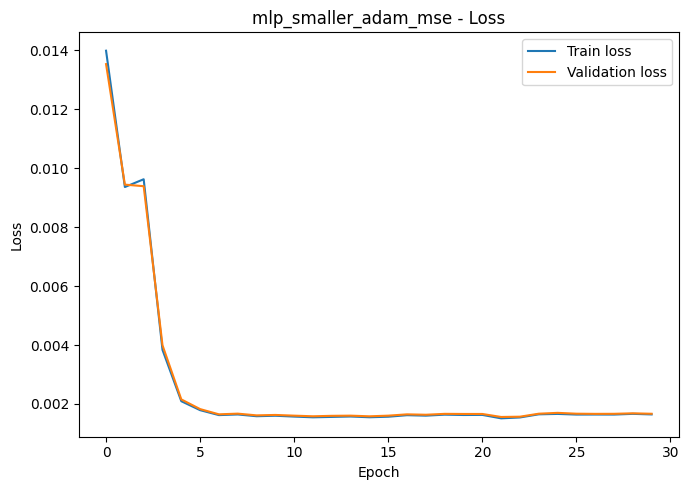

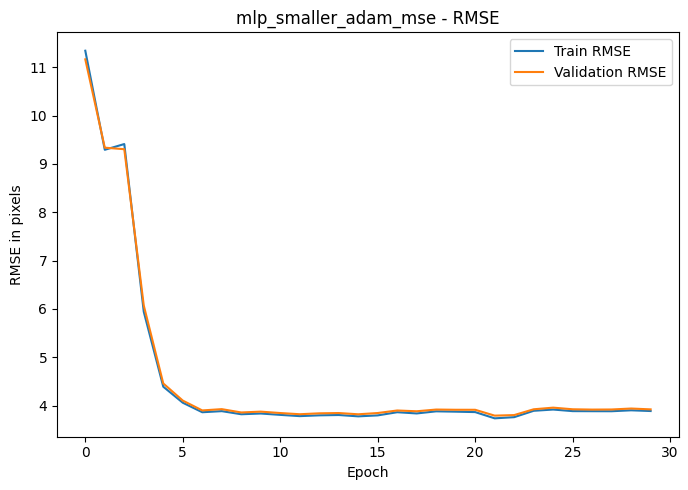

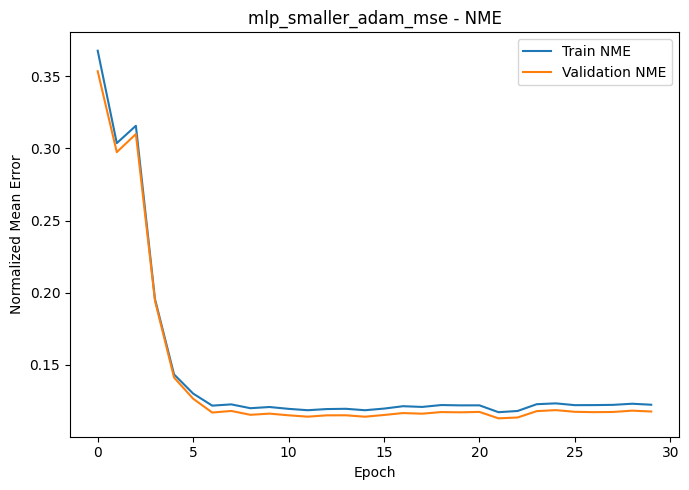

,model,architecture,optimizer,loss,rmse,mae,normalized_mean_error,experiment_name
0,mean_keypoint_baseline,constant_mean_prediction,none,none,3.907841,2.648260,0.116925,NaN
1,mlp,"(256, 128)",adam,masked_mse,3.791402,2.566219,0.112872,mlp_smaller_adam_mse


Final test metrics:
{'rmse': 3.702392816543579, 'mae': 2.5617315769195557, 'nme': 0.11516029387712479, 'loss': 0.0014947197872299885}
Running experiment: mlp_large_dropout_adam_mse
Epoch 001/40 | Train Loss: 0.03647 | Val Loss: 0.03556 | Train RMSE: 18.3468 | Val RMSE: 18.0972 | Train NME: 0.6519 | Val NME: 0.6372
Epoch 002/40 | Train Loss: 0.04206 | Val Loss: 0.04187 | Train RMSE: 19.6891 | Val RMSE: 19.6383 | Train NME: 0.7311 | Val NME: 0.7234
Epoch 003/40 | Train Loss: 0.00473 | Val Loss: 0.00473 | Train RMSE: 6.5951 | Val RMSE: 6.5968 | Train NME: 0.2297 | Val NME: 0.2249
Epoch 004/40 | Train Loss: 0.00165 | Val Loss: 0.00168 | Train RMSE: 3.8978 | Val RMSE: 3.9303 | Train NME: 0.1228 | Val NME: 0.1180
Epoch 005/40 | Train Loss: 0.00165 | Val Loss: 0.00167 | Train RMSE: 3.8986 | Val RMSE: 3.9266 | Train NME: 0.1230 | Val NME: 0.1181
Epoch 006/40 | Train Loss: 0.00169 | Val Loss: 0.00172 | Train RMSE: 3.9510 | Val RMSE: 3.9860 | Train NME: 0.1252 | Val NME: 0.1204
Epoch 007/40 | Tr

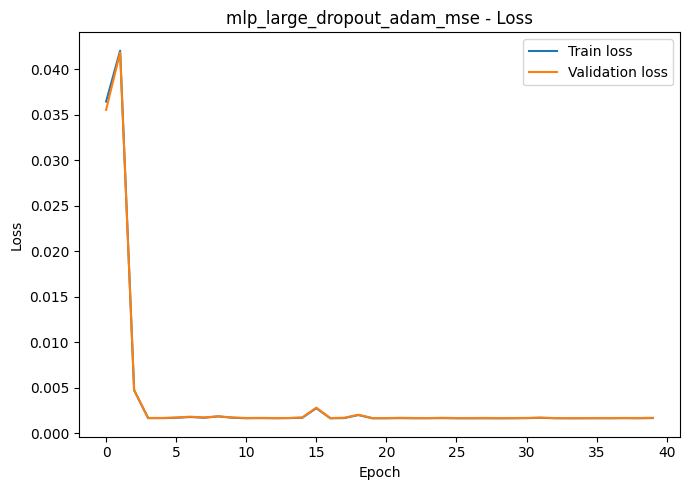

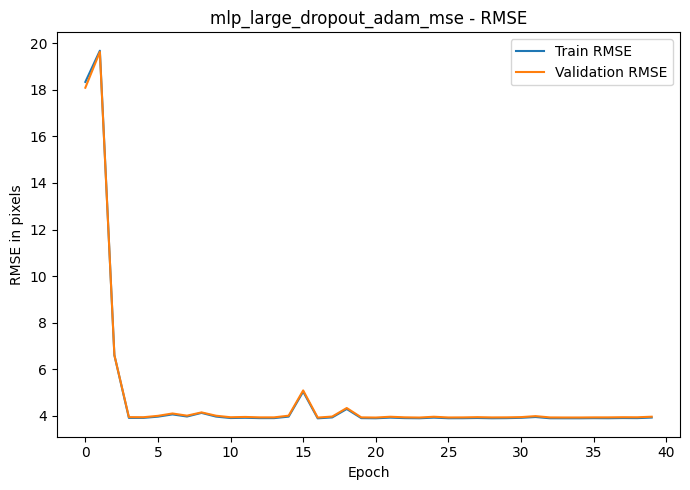

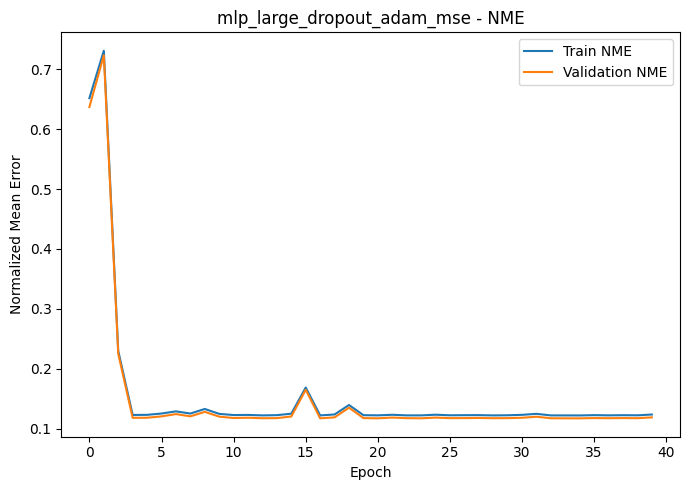

,model,architecture,optimizer,loss,rmse,mae,normalized_mean_error,experiment_name
0,mean_keypoint_baseline,constant_mean_prediction,none,none,3.907841,2.648260,0.116925,NaN
1,mlp,"(256, 128)",adam,masked_mse,3.791402,2.566219,0.112872,mlp_smaller_adam_mse
2,mlp,"(1024, 512, 256)",adam,masked_mse,3.911745,2.652725,0.117171,mlp_large_dropout_adam_mse


Final test metrics:
{'rmse': 3.841238498687744, 'mae': 2.666806221008301, 'nme': 0.12006599456071854, 'loss': 0.0016089958891748115}
Running experiment: mlp_adam_smooth_l1
Epoch 001/30 | Train Loss: 0.00833 | Val Loss: 0.00794 | Train RMSE: 12.3886 | Val RMSE: 12.0912 | Train NME: 0.4057 | Val NME: 0.3957
Epoch 002/30 | Train Loss: 0.00762 | Val Loss: 0.00752 | Train RMSE: 11.8597 | Val RMSE: 11.7719 | Train NME: 0.4148 | Val NME: 0.4077
Epoch 003/30 | Train Loss: 0.00380 | Val Loss: 0.00379 | Train RMSE: 8.3581 | Val RMSE: 8.3483 | Train NME: 0.2961 | Val NME: 0.2911
Epoch 004/30 | Train Loss: 0.00081 | Val Loss: 0.00083 | Train RMSE: 3.8822 | Val RMSE: 3.9162 | Train NME: 0.1219 | Val NME: 0.1171
Epoch 005/30 | Train Loss: 0.00086 | Val Loss: 0.00088 | Train RMSE: 3.9908 | Val RMSE: 4.0318 | Train NME: 0.1269 | Val NME: 0.1223
Epoch 006/30 | Train Loss: 0.00087 | Val Loss: 0.00088 | Train RMSE: 3.9956 | Val RMSE: 4.0304 | Train NME: 0.1266 | Val NME: 0.1219
Epoch 007/30 | Train Loss:

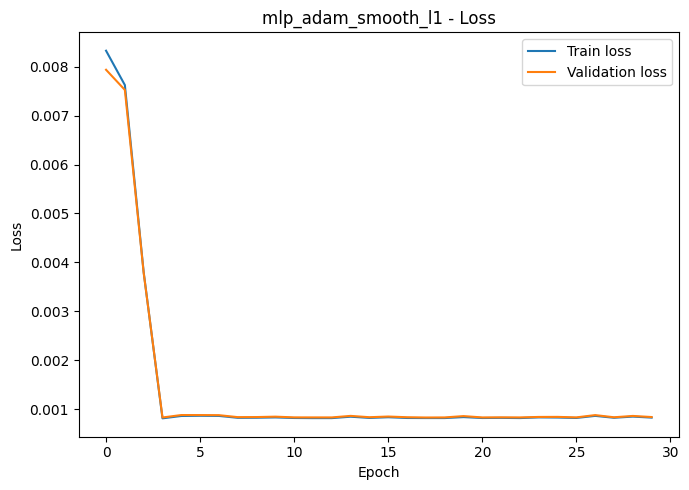

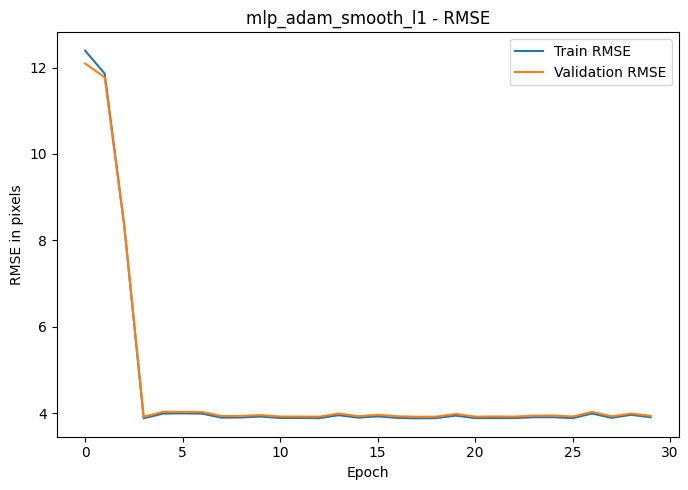

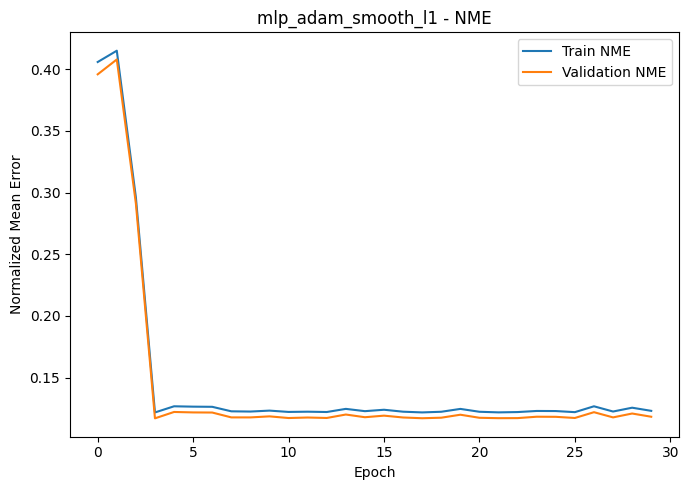

,model,architecture,optimizer,loss,rmse,mae,normalized_mean_error,experiment_name
0,mean_keypoint_baseline,constant_mean_prediction,none,none,3.907841,2.648260,0.116925,NaN
1,mlp,"(256, 128)",adam,masked_mse,3.791402,2.566219,0.112872,mlp_smaller_adam_mse
2,mlp,"(1024, 512, 256)",adam,masked_mse,3.911745,2.652725,0.117171,mlp_large_dropout_adam_mse
3,mlp,"(512, 256, 128)",adam,masked_smooth_l1,3.915837,2.659091,0.117211,mlp_adam_smooth_l1


Final test metrics:
{'rmse': 3.8426010608673096, 'mae': 2.668025255203247, 'nme': 0.1200079619884491, 'loss': 0.0008045987430552624}
Running experiment: mlp_sgd_mse
Epoch 001/50 | Train Loss: 0.01211 | Val Loss: 0.01148 | Train RMSE: 10.5841 | Val RMSE: 10.2848 | Train NME: 0.3387 | Val NME: 0.3298
Epoch 002/50 | Train Loss: 0.00901 | Val Loss: 0.00855 | Train RMSE: 9.1024 | Val RMSE: 8.8755 | Train NME: 0.2909 | Val NME: 0.2824
Epoch 003/50 | Train Loss: 0.00784 | Val Loss: 0.00743 | Train RMSE: 8.5144 | Val RMSE: 8.2784 | Train NME: 0.2732 | Val NME: 0.2655
Epoch 004/50 | Train Loss: 0.00606 | Val Loss: 0.00576 | Train RMSE: 7.4877 | Val RMSE: 7.2920 | Train NME: 0.2408 | Val NME: 0.2341
Epoch 005/50 | Train Loss: 0.00499 | Val Loss: 0.00475 | Train RMSE: 6.7907 | Val RMSE: 6.6186 | Train NME: 0.2195 | Val NME: 0.2130
Epoch 006/50 | Train Loss: 0.00395 | Val Loss: 0.00380 | Train RMSE: 6.0360 | Val RMSE: 5.9254 | Train NME: 0.1963 | Val NME: 0.1906
Epoch 007/50 | Train Loss: 0.00377 

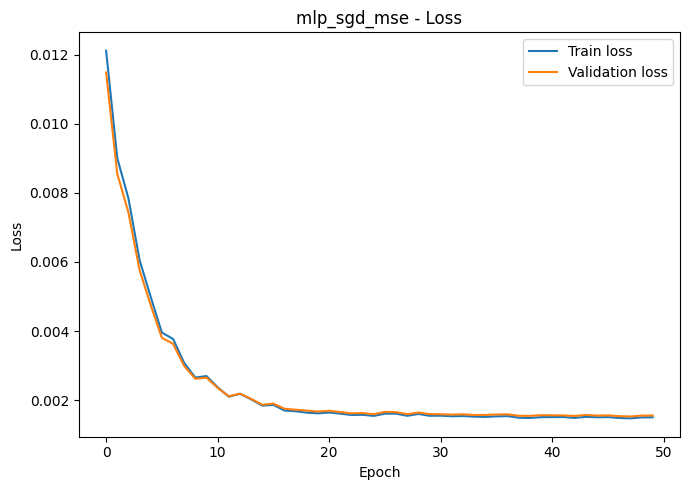

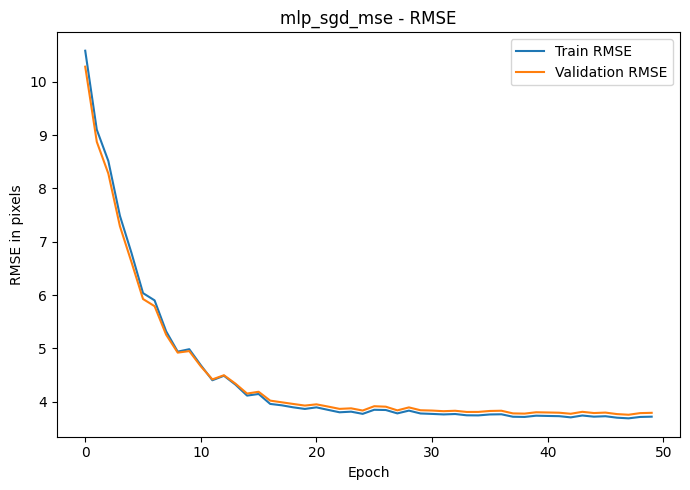

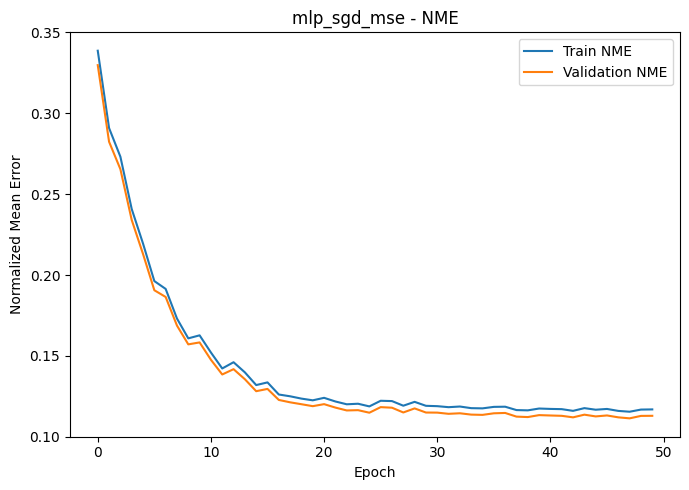

,model,architecture,optimizer,loss,rmse,mae,normalized_mean_error,experiment_name
0,mean_keypoint_baseline,constant_mean_prediction,none,none,3.907841,2.648260,0.116925,NaN
1,mlp,"(256, 128)",adam,masked_mse,3.791402,2.566219,0.112872,mlp_smaller_adam_mse
2,mlp,"(1024, 512, 256)",adam,masked_mse,3.911745,2.652725,0.117171,mlp_large_dropout_adam_mse
3,mlp,"(512, 256, 128)",adam,masked_smooth_l1,3.915837,2.659091,0.117211,mlp_adam_smooth_l1
4,mlp,"(512, 256, 128)",sgd,masked_mse,3.753970,2.527895,0.111361,mlp_sgd_mse


Final test metrics:
{'rmse': 3.685457706451416, 'mae': 2.548678398132324, 'nme': 0.11464805901050568, 'loss': 0.0014813114139284437}


In [ ]:
# Run the selected MLP experiments

mlp_experiments = [
    {
        "experiment_name": "mlp_smaller_adam_mse",
        "model_family": "mlp",
        "hidden_layers": (256, 128),
        "dropout": 0.2,
        "activation": "relu",
        "batch_size": 64,
        "epochs": 30,
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "loss_function": "masked_mse"
    },
    {
        "experiment_name": "mlp_large_dropout_adam_mse",
        "model_family": "mlp",
        "hidden_layers": (1024, 512, 256),
        "dropout": 0.4,
        "activation": "relu",
        "batch_size": 64,
        "epochs": 40,
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "weight_decay": 1e-5,
        "loss_function": "masked_mse"
    },
    {
        "experiment_name": "mlp_adam_smooth_l1",
        "model_family": "mlp",
        "hidden_layers": (512, 256, 128),
        "dropout": 0.2,
        "activation": "relu",
        "batch_size": 64,
        "epochs": 30,
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "loss_function": "masked_smooth_l1"
    },
    {
        "experiment_name": "mlp_sgd_mse",
        "model_family": "mlp",
        "hidden_layers": (512, 256, 128),
        "dropout": 0.2,
        "activation": "relu",
        "batch_size": 64,
        "epochs": 50,
        "optimizer": "sgd",
        "learning_rate": 1e-2,
        "weight_decay": 0.0,
        "loss_function": "masked_mse"
    }
]

mlp_outputs = {}

for config in mlp_experiments:
    config["architecture_label"] = str(config["hidden_layers"])

    model_kwargs = {
        "input_dim": 96 * 96,
        "output_dim": len(KEYPOINT_COLUMNS),
        "hidden_layers": config["hidden_layers"],
        "dropout": config["dropout"],
        "activation": config["activation"]
    }

    trained_model, history_df, test_metrics, summary_df = run_experiment(
        config=config,
        model_class=ConfigurableMLP,
        model_kwargs=model_kwargs,
        image_mode="flat",
        augment_train=False
    )

    mlp_outputs[config["experiment_name"]] = {
        "model": trained_model,
        "history": history_df,
        "test_metrics": test_metrics,
        "summary": summary_df
    }

**Section 5 - CNN simple**

In [ ]:
# Define the configurable CNN model with simple and complex presets

class ConfigurableCNN(nn.Module):
    def __init__(
        self,
        input_channels=1,
        output_dim=30,
        model_size="simple",
        conv_channels=None,
        dense_layers=None,
        dropout=0.2,
        use_batch_norm=False,
        activation="relu"
    ):
        super().__init__()

        preset = self._get_preset(model_size)

        if conv_channels is None:
            conv_channels = preset["conv_channels"]

        if dense_layers is None:
            dense_layers = preset["dense_layers"]

        conv_layers = []
        previous_channels = input_channels

        for out_channels in conv_channels:
            conv_layers.append(nn.Conv2d(previous_channels, out_channels, kernel_size=3, padding=1))

            if use_batch_norm:
                conv_layers.append(nn.BatchNorm2d(out_channels))

            conv_layers.append(self._get_activation(activation))
            conv_layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

            if dropout > 0:
                conv_layers.append(nn.Dropout2d(dropout))

            previous_channels = out_channels

        self.feature_extractor = nn.Sequential(*conv_layers)

        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, 96, 96)
            dummy_output = self.feature_extractor(dummy_input)
            flattened_dim = dummy_output.view(1, -1).shape[1]

        dense_blocks = []
        previous_dim = flattened_dim

        for hidden_dim in dense_layers:
            dense_blocks.append(nn.Linear(previous_dim, hidden_dim))
            dense_blocks.append(self._get_activation(activation))

            if dropout > 0:
                dense_blocks.append(nn.Dropout(dropout))

            previous_dim = hidden_dim

        dense_blocks.append(nn.Linear(previous_dim, output_dim))

        self.regressor = nn.Sequential(*dense_blocks)

    def _get_preset(self, model_size):
        if model_size == "simple":
            return {
                "conv_channels": (32, 64, 128),
                "dense_layers": (256,)
            }
        elif model_size == "complex":
            return {
                "conv_channels": (32, 64, 128, 256),
                "dense_layers": (512, 256)
            }
        else:
            raise ValueError(f"Unsupported model_size: {model_size}")

    def _get_activation(self, activation):
        if activation == "relu":
            return nn.ReLU()
        elif activation == "leaky_relu":
            return nn.LeakyReLU()
        elif activation == "elu":
            return nn.ELU()
        else:
            raise ValueError(f"Unsupported activation function: {activation}")

    def forward(self, x):
        features = self.feature_extractor(x)
        features = features.view(features.size(0), -1)
        outputs = self.regressor(features)
        return outputs


cnn_model_check = ConfigurableCNN(
    model_size="simple",
    output_dim=len(KEYPOINT_COLUMNS)
).to(DEVICE)

sample_batch = next(iter(train_cnn_loader))
sample_images = sample_batch["image"].to(DEVICE)

with torch.no_grad():
    sample_outputs = cnn_model_check(sample_images)

print("Sample CNN input shape:", sample_images.shape)
print("Sample CNN output shape:", sample_outputs.shape)

Sample CNN input shape: torch.Size([64, 1, 96, 96])
Sample CNN output shape: torch.Size([64, 30])


Running experiment: cnn_simple_adam_mse
Epoch 001/30 | Train Loss: 0.00260 | Val Loss: 0.00263 | Train RMSE: 4.8859 | Val RMSE: 4.9279 | Train NME: 0.1638 | Val NME: 0.1595
Epoch 002/30 | Train Loss: 0.00200 | Val Loss: 0.00203 | Train RMSE: 4.2888 | Val RMSE: 4.3199 | Train NME: 0.1388 | Val NME: 0.1341
Epoch 003/30 | Train Loss: 0.00187 | Val Loss: 0.00191 | Train RMSE: 4.1518 | Val RMSE: 4.1927 | Train NME: 0.1342 | Val NME: 0.1297
Epoch 004/30 | Train Loss: 0.00190 | Val Loss: 0.00193 | Train RMSE: 4.1770 | Val RMSE: 4.2126 | Train NME: 0.1340 | Val NME: 0.1295
Epoch 005/30 | Train Loss: 0.00167 | Val Loss: 0.00169 | Train RMSE: 3.9220 | Val RMSE: 3.9465 | Train NME: 0.1243 | Val NME: 0.1194
Epoch 006/30 | Train Loss: 0.00216 | Val Loss: 0.00219 | Train RMSE: 4.4508 | Val RMSE: 4.4914 | Train NME: 0.1462 | Val NME: 0.1420
Epoch 007/30 | Train Loss: 0.00205 | Val Loss: 0.00208 | Train RMSE: 4.3385 | Val RMSE: 4.3746 | Train NME: 0.1402 | Val NME: 0.1358
Epoch 008/30 | Train Loss: 0.

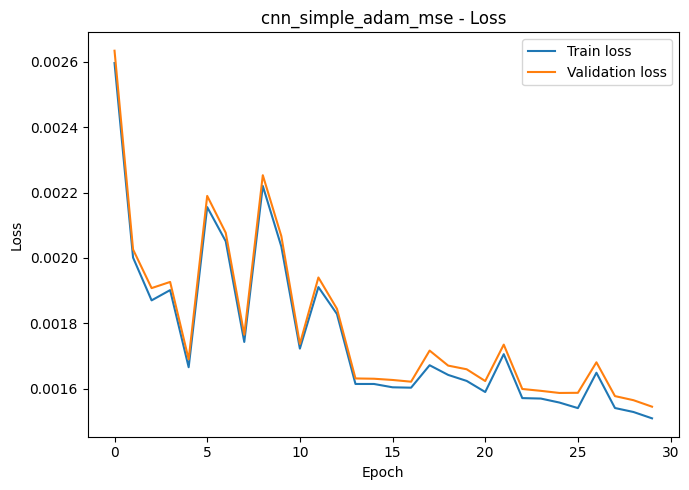

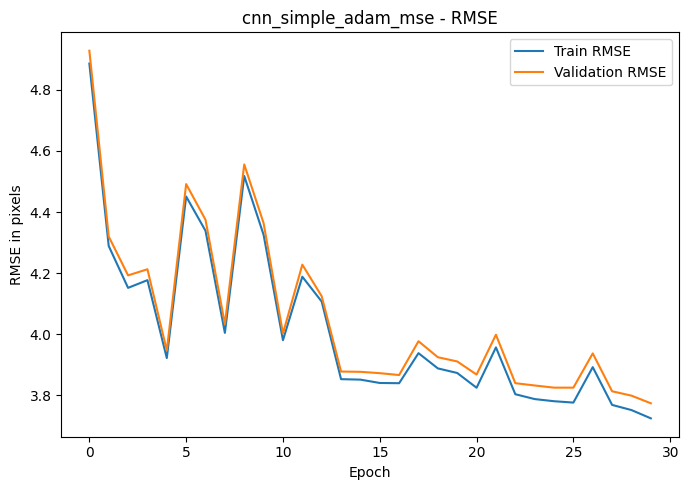

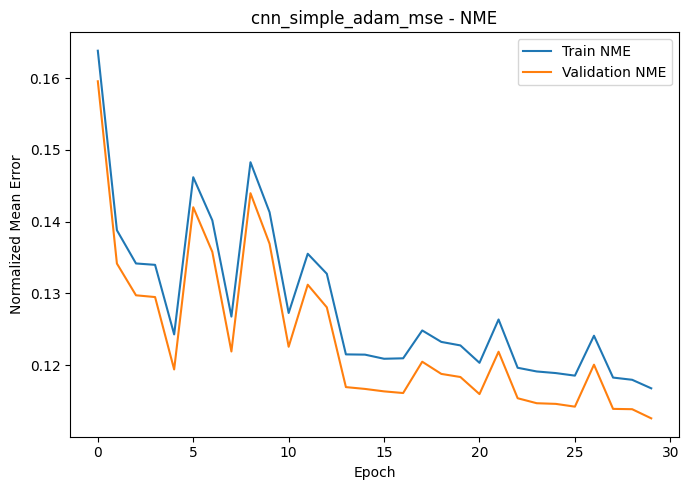

,model,architecture,optimizer,loss,rmse,mae,normalized_mean_error,experiment_name
0,mean_keypoint_baseline,constant_mean_prediction,none,none,3.907841,2.648260,0.116925,NaN
1,mlp,"(256, 128)",adam,masked_mse,3.791402,2.566219,0.112872,mlp_smaller_adam_mse
2,mlp,"(1024, 512, 256)",adam,masked_mse,3.911745,2.652725,0.117171,mlp_large_dropout_adam_mse
3,mlp,"(512, 256, 128)",adam,masked_smooth_l1,3.915837,2.659091,0.117211,mlp_adam_smooth_l1
4,mlp,"(512, 256, 128)",sgd,masked_mse,3.753970,2.527895,0.111361,mlp_sgd_mse
5,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.773986,2.561119,0.112581,cnn_simple_adam_mse


Final test metrics:
{'rmse': 3.7052202224731445, 'mae': 2.5695605278015137, 'nme': 0.11533792316913605, 'loss': 0.001498249861143142}
Running experiment: cnn_simple_smaller_adam_mse
Epoch 001/30 | Train Loss: 0.00495 | Val Loss: 0.00501 | Train RMSE: 6.7496 | Val RMSE: 6.7939 | Train NME: 0.2363 | Val NME: 0.2327
Epoch 002/30 | Train Loss: 0.00228 | Val Loss: 0.00230 | Train RMSE: 4.5661 | Val RMSE: 4.6037 | Train NME: 0.1512 | Val NME: 0.1468
Epoch 003/30 | Train Loss: 0.00172 | Val Loss: 0.00174 | Train RMSE: 3.9828 | Val RMSE: 4.0094 | Train NME: 0.1267 | Val NME: 0.1217
Epoch 004/30 | Train Loss: 0.00167 | Val Loss: 0.00170 | Train RMSE: 3.9232 | Val RMSE: 3.9564 | Train NME: 0.1241 | Val NME: 0.1192
Epoch 005/30 | Train Loss: 0.00174 | Val Loss: 0.00176 | Train RMSE: 4.0084 | Val RMSE: 4.0288 | Train NME: 0.1283 | Val NME: 0.1233
Epoch 006/30 | Train Loss: 0.00309 | Val Loss: 0.00313 | Train RMSE: 5.3314 | Val RMSE: 5.3685 | Train NME: 0.1831 | Val NME: 0.1790
Epoch 007/30 | Train

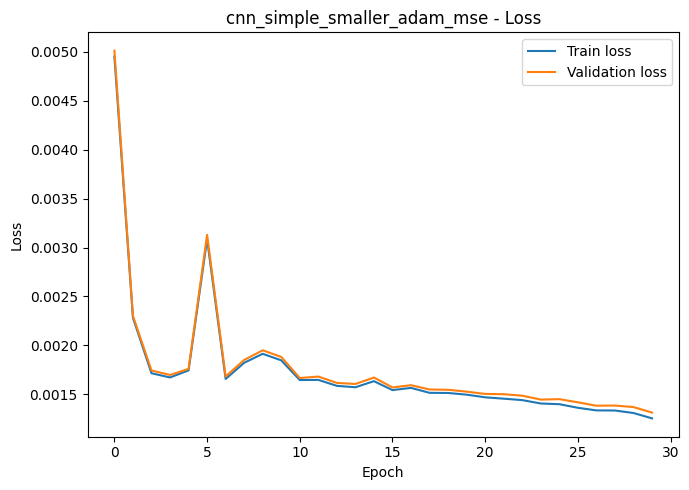

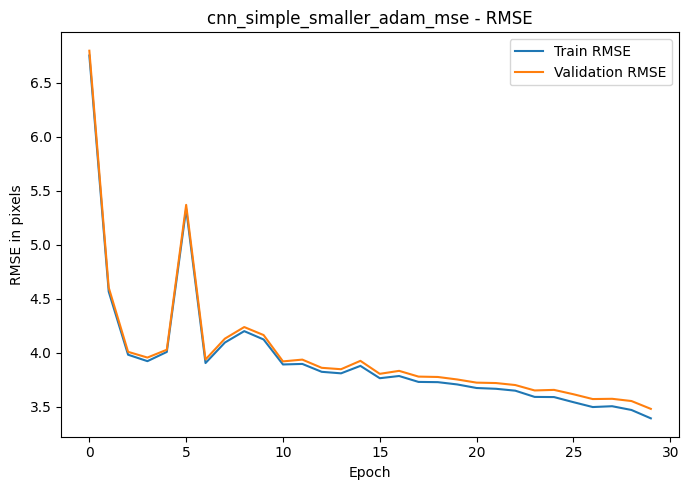

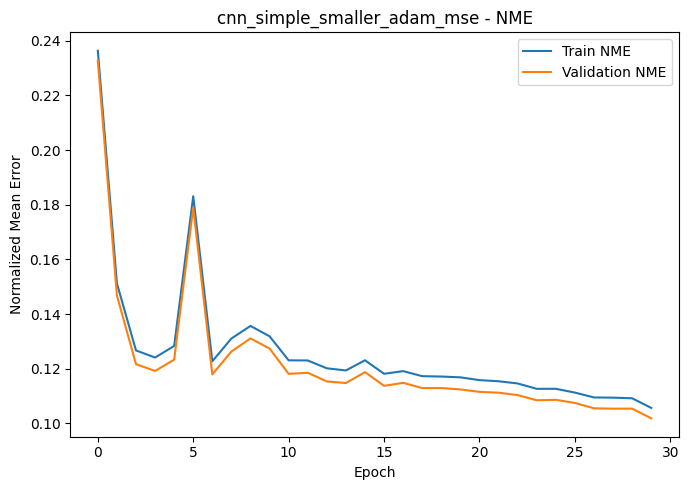

,model,architecture,optimizer,loss,rmse,mae,normalized_mean_error,experiment_name
0,mean_keypoint_baseline,constant_mean_prediction,none,none,3.907841,2.648260,0.116925,NaN
1,mlp,"(256, 128)",adam,masked_mse,3.791402,2.566219,0.112872,mlp_smaller_adam_mse
2,mlp,"(1024, 512, 256)",adam,masked_mse,3.911745,2.652725,0.117171,mlp_large_dropout_adam_mse
3,mlp,"(512, 256, 128)",adam,masked_smooth_l1,3.915837,2.659091,0.117211,mlp_adam_smooth_l1
4,mlp,"(512, 256, 128)",sgd,masked_mse,3.753970,2.527895,0.111361,mlp_sgd_mse
5,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.773986,2.561119,0.112581,cnn_simple_adam_mse
6,cnn,"simple | conv=(16, 32, 64) | dense=(128,)",adam,masked_mse,3.481961,2.309657,0.101834,cnn_simple_smaller_adam_mse


Final test metrics:
{'rmse': 3.38159441947937, 'mae': 2.315739393234253, 'nme': 0.10421819984912872, 'loss': 0.0012491019486711662}
Running experiment: cnn_simple_dropout_adam_mse
Epoch 001/40 | Train Loss: 0.00905 | Val Loss: 0.00916 | Train RMSE: 9.1207 | Val RMSE: 9.1764 | Train NME: 0.3258 | Val NME: 0.3225
Epoch 002/40 | Train Loss: 0.00558 | Val Loss: 0.00565 | Train RMSE: 7.1770 | Val RMSE: 7.2138 | Train NME: 0.2558 | Val NME: 0.2519
Epoch 003/40 | Train Loss: 0.00378 | Val Loss: 0.00384 | Train RMSE: 5.9012 | Val RMSE: 5.9484 | Train NME: 0.2057 | Val NME: 0.2020
Epoch 004/40 | Train Loss: 0.00462 | Val Loss: 0.00469 | Train RMSE: 6.5226 | Val RMSE: 6.5727 | Train NME: 0.2314 | Val NME: 0.2278
Epoch 005/40 | Train Loss: 0.00454 | Val Loss: 0.00460 | Train RMSE: 6.4617 | Val RMSE: 6.5057 | Train NME: 0.2275 | Val NME: 0.2237
Epoch 006/40 | Train Loss: 0.00225 | Val Loss: 0.00229 | Train RMSE: 4.5523 | Val RMSE: 4.5945 | Train NME: 0.1496 | Val NME: 0.1452
Epoch 007/40 | Train L

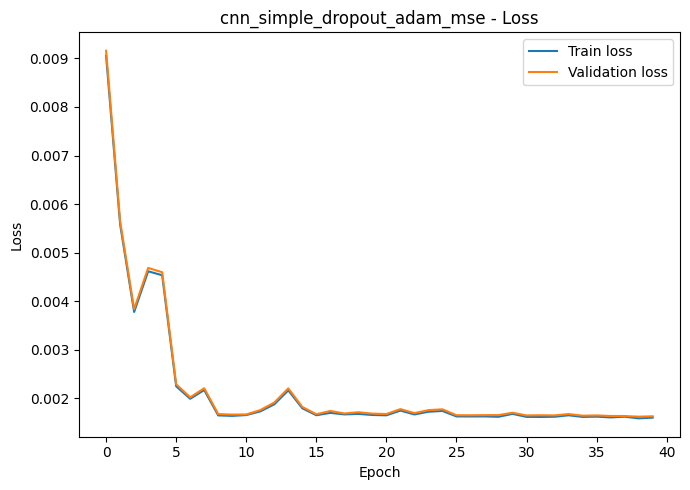

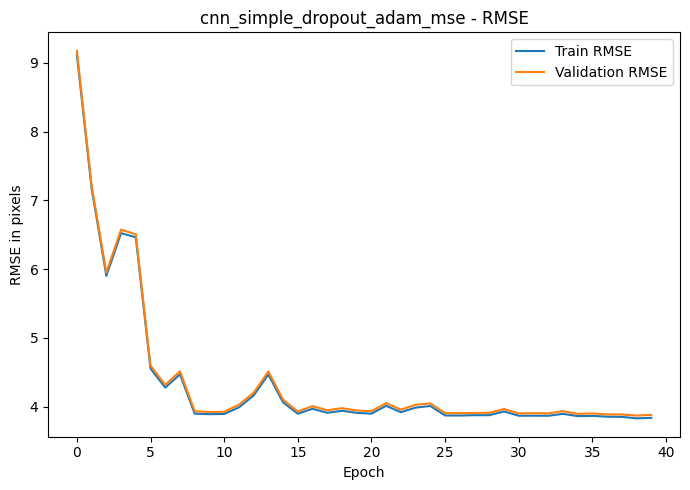

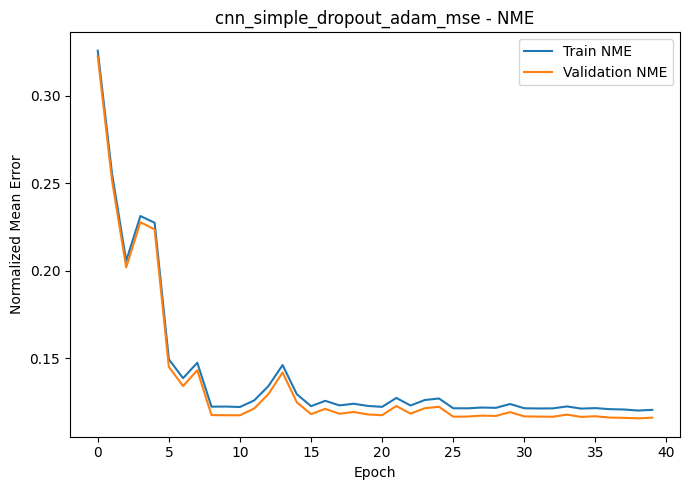

,model,architecture,optimizer,loss,rmse,mae,normalized_mean_error,experiment_name
0,mean_keypoint_baseline,constant_mean_prediction,none,none,3.907841,2.648260,0.116925,NaN
1,mlp,"(256, 128)",adam,masked_mse,3.791402,2.566219,0.112872,mlp_smaller_adam_mse
2,mlp,"(1024, 512, 256)",adam,masked_mse,3.911745,2.652725,0.117171,mlp_large_dropout_adam_mse
3,mlp,"(512, 256, 128)",adam,masked_smooth_l1,3.915837,2.659091,0.117211,mlp_adam_smooth_l1
4,mlp,"(512, 256, 128)",sgd,masked_mse,3.753970,2.527895,0.111361,mlp_sgd_mse
5,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.773986,2.561119,0.112581,cnn_simple_adam_mse
6,cnn,"simple | conv=(16, 32, 64) | dense=(128,)",adam,masked_mse,3.481961,2.309657,0.101834,cnn_simple_smaller_adam_mse
7,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.868397,2.629376,0.115810,cnn_simple_dropout_adam_mse


Final test metrics:
{'rmse': 3.7897238731384277, 'mae': 2.632026433944702, 'nme': 0.1183670312166214, 'loss': 0.0015660199569538236}
Running experiment: cnn_simple_smooth_l1
Epoch 001/30 | Train Loss: 0.00161 | Val Loss: 0.00162 | Train RMSE: 5.4495 | Val RMSE: 5.4695 | Train NME: 0.1866 | Val NME: 0.1821
Epoch 002/30 | Train Loss: 0.00100 | Val Loss: 0.00101 | Train RMSE: 4.2793 | Val RMSE: 4.3248 | Train NME: 0.1379 | Val NME: 0.1337
Epoch 003/30 | Train Loss: 0.00102 | Val Loss: 0.00103 | Train RMSE: 4.3303 | Val RMSE: 4.3676 | Train NME: 0.1417 | Val NME: 0.1374
Epoch 004/30 | Train Loss: 0.00123 | Val Loss: 0.00125 | Train RMSE: 4.7597 | Val RMSE: 4.8080 | Train NME: 0.1585 | Val NME: 0.1549
Epoch 005/30 | Train Loss: 0.00083 | Val Loss: 0.00084 | Train RMSE: 3.9100 | Val RMSE: 3.9407 | Train NME: 0.1237 | Val NME: 0.1189
Epoch 006/30 | Train Loss: 0.00082 | Val Loss: 0.00084 | Train RMSE: 3.8956 | Val RMSE: 3.9288 | Train NME: 0.1229 | Val NME: 0.1180
Epoch 007/30 | Train Loss: 0

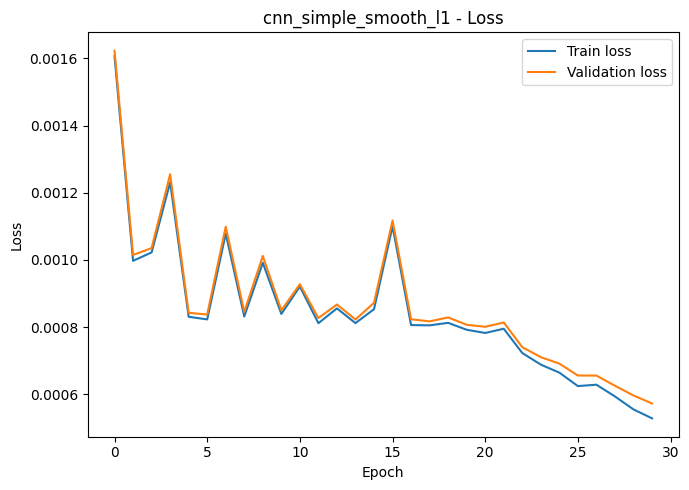

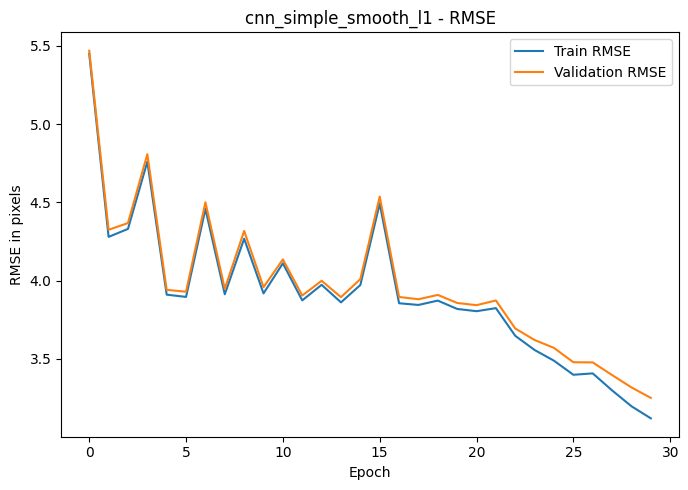

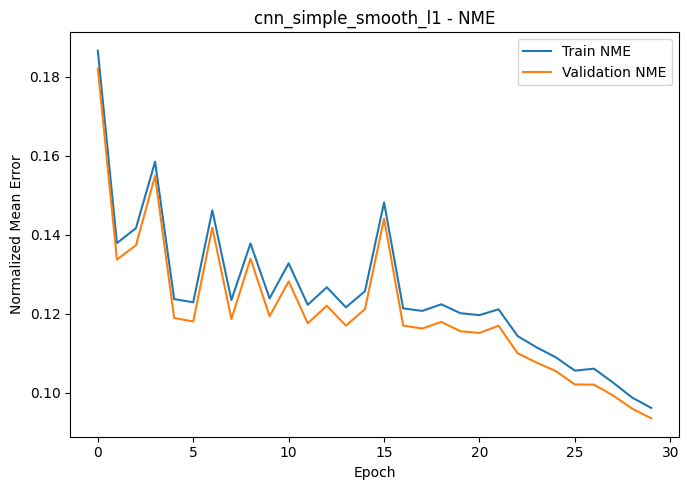

,model,architecture,optimizer,loss,rmse,mae,normalized_mean_error,experiment_name
0,mean_keypoint_baseline,constant_mean_prediction,none,none,3.907841,2.648260,0.116925,NaN
1,mlp,"(256, 128)",adam,masked_mse,3.791402,2.566219,0.112872,mlp_smaller_adam_mse
2,mlp,"(1024, 512, 256)",adam,masked_mse,3.911745,2.652725,0.117171,mlp_large_dropout_adam_mse
3,mlp,"(512, 256, 128)",adam,masked_smooth_l1,3.915837,2.659091,0.117211,mlp_adam_smooth_l1
4,mlp,"(512, 256, 128)",sgd,masked_mse,3.753970,2.527895,0.111361,mlp_sgd_mse
5,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.773986,2.561119,0.112581,cnn_simple_adam_mse
6,cnn,"simple | conv=(16, 32, 64) | dense=(128,)",adam,masked_mse,3.481961,2.309657,0.101834,cnn_simple_smaller_adam_mse
7,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.868397,2.629376,0.115810,cnn_simple_dropout_adam_mse
8,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_smooth_l1,3.250028,2.123828,0.093494,cnn_simple_smooth_l1


Final test metrics:
{'rmse': 3.1100850105285645, 'mae': 2.118434190750122, 'nme': 0.09520254284143448, 'loss': 0.0005288404592419656}
Running experiment: cnn_simple_sgd_mse
Epoch 001/50 | Train Loss: 0.00782 | Val Loss: 0.00790 | Train RMSE: 8.4866 | Val RMSE: 8.5290 | Train NME: 0.3071 | Val NME: 0.3040
Epoch 002/50 | Train Loss: 0.00721 | Val Loss: 0.00734 | Train RMSE: 8.1549 | Val RMSE: 8.2231 | Train NME: 0.2935 | Val NME: 0.2912
Epoch 003/50 | Train Loss: 0.00623 | Val Loss: 0.00633 | Train RMSE: 7.5680 | Val RMSE: 7.6364 | Train NME: 0.2716 | Val NME: 0.2691
Epoch 004/50 | Train Loss: 0.00673 | Val Loss: 0.00685 | Train RMSE: 7.8739 | Val RMSE: 7.9461 | Train NME: 0.2840 | Val NME: 0.2815
Epoch 005/50 | Train Loss: 0.00528 | Val Loss: 0.00539 | Train RMSE: 6.9746 | Val RMSE: 7.0455 | Train NME: 0.2481 | Val NME: 0.2455
Epoch 006/50 | Train Loss: 0.00497 | Val Loss: 0.00508 | Train RMSE: 6.7678 | Val RMSE: 6.8396 | Train NME: 0.2399 | Val NME: 0.2372
Epoch 007/50 | Train Loss: 0.

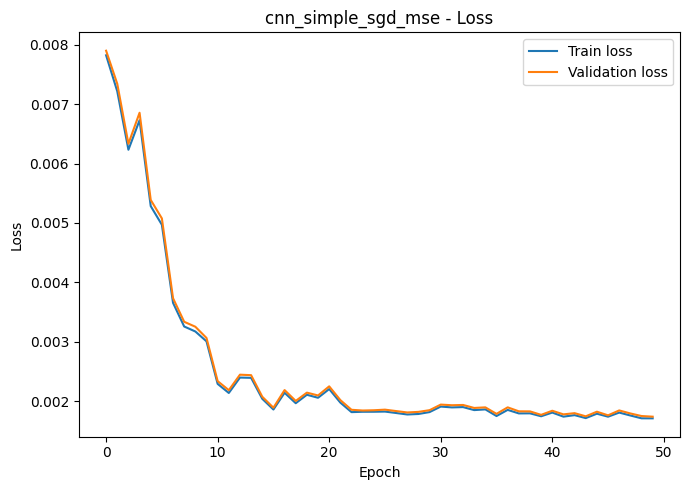

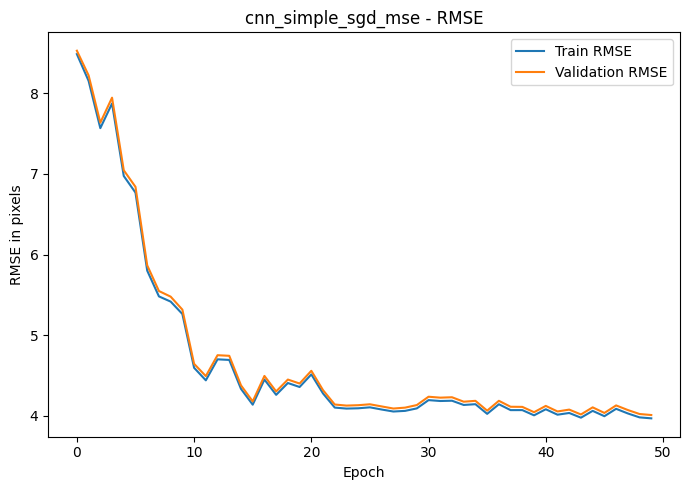

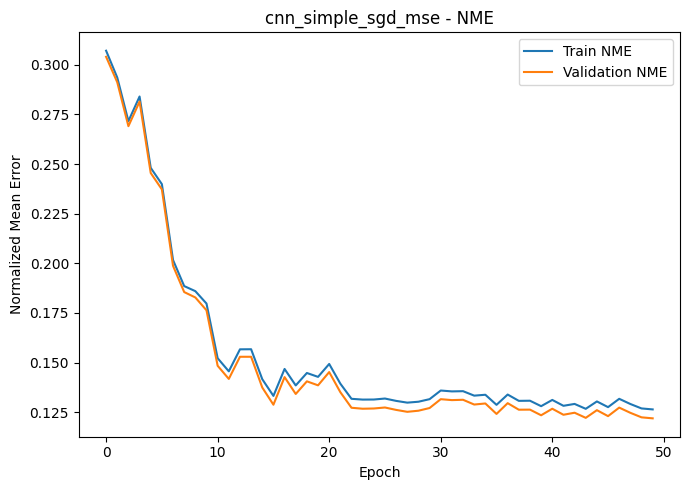

,model,architecture,optimizer,loss,rmse,mae,normalized_mean_error,experiment_name
0,mean_keypoint_baseline,constant_mean_prediction,none,none,3.907841,2.648260,0.116925,NaN
1,mlp,"(256, 128)",adam,masked_mse,3.791402,2.566219,0.112872,mlp_smaller_adam_mse
2,mlp,"(1024, 512, 256)",adam,masked_mse,3.911745,2.652725,0.117171,mlp_large_dropout_adam_mse
3,mlp,"(512, 256, 128)",adam,masked_smooth_l1,3.915837,2.659091,0.117211,mlp_adam_smooth_l1
4,mlp,"(512, 256, 128)",sgd,masked_mse,3.753970,2.527895,0.111361,mlp_sgd_mse
5,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.773986,2.561119,0.112581,cnn_simple_adam_mse
6,cnn,"simple | conv=(16, 32, 64) | dense=(128,)",adam,masked_mse,3.481961,2.309657,0.101834,cnn_simple_smaller_adam_mse
7,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.868397,2.629376,0.115810,cnn_simple_dropout_adam_mse
8,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_smooth_l1,3.250028,2.123828,0.093494,cnn_simple_smooth_l1
9,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",sgd,masked_mse,4.008184,2.774023,0.121907,cnn_simple_sgd_mse


Final test metrics:
{'rmse': 3.9018101692199707, 'mae': 2.7632601261138916, 'nme': 0.12366026639938354, 'loss': 0.001658109933452738}


In [ ]:
# Run the selected simple CNN experiments

cnn_simple_experiments = [
    {
        "experiment_name": "cnn_simple_adam_mse",
        "model_family": "cnn",
        "model_size": "simple",
        "conv_channels": (32, 64, 128),
        "dense_layers": (256,),
        "dropout": 0.2,
        "use_batch_norm": False,
        "activation": "relu",
        "batch_size": 64,
        "epochs": 30,
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "loss_function": "masked_mse"
    },
    {
        "experiment_name": "cnn_simple_smaller_adam_mse",
        "model_family": "cnn",
        "model_size": "simple",
        "conv_channels": (16, 32, 64),
        "dense_layers": (128,),
        "dropout": 0.2,
        "use_batch_norm": False,
        "activation": "relu",
        "batch_size": 64,
        "epochs": 30,
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "loss_function": "masked_mse"
    },
    {
        "experiment_name": "cnn_simple_dropout_adam_mse",
        "model_family": "cnn",
        "model_size": "simple",
        "conv_channels": (32, 64, 128),
        "dense_layers": (256,),
        "dropout": 0.35,
        "use_batch_norm": False,
        "activation": "relu",
        "batch_size": 64,
        "epochs": 40,
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "weight_decay": 1e-5,
        "loss_function": "masked_mse"
    },
    {
        "experiment_name": "cnn_simple_smooth_l1",
        "model_family": "cnn",
        "model_size": "simple",
        "conv_channels": (32, 64, 128),
        "dense_layers": (256,),
        "dropout": 0.2,
        "use_batch_norm": False,
        "activation": "relu",
        "batch_size": 64,
        "epochs": 30,
        "optimizer": "adam",
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "loss_function": "masked_smooth_l1"
    },
    {
        "experiment_name": "cnn_simple_sgd_mse",
        "model_family": "cnn",
        "model_size": "simple",
        "conv_channels": (32, 64, 128),
        "dense_layers": (256,),
        "dropout": 0.2,
        "use_batch_norm": False,
        "activation": "relu",
        "batch_size": 64,
        "epochs": 50,
        "optimizer": "sgd",
        "learning_rate": 1e-2,
        "weight_decay": 0.0,
        "loss_function": "masked_mse"
    }
]

cnn_simple_outputs = {}

for config in cnn_simple_experiments:
    config["architecture_label"] = (
        f"{config['model_size']} | "
        f"conv={config['conv_channels']} | "
        f"dense={config['dense_layers']}"
    )

    model_kwargs = {
        "input_channels": 1,
        "output_dim": len(KEYPOINT_COLUMNS),
        "model_size": config["model_size"],
        "conv_channels": config["conv_channels"],
        "dense_layers": config["dense_layers"],
        "dropout": config["dropout"],
        "use_batch_norm": config["use_batch_norm"],
        "activation": config["activation"]
    }

    trained_model, history_df, test_metrics, summary_df = run_experiment(
        config=config,
        model_class=ConfigurableCNN,
        model_kwargs=model_kwargs,
        image_mode="cnn",
        augment_train=False
    )

    cnn_simple_outputs[config["experiment_name"]] = {
        "model": trained_model,
        "history": history_df,
        "test_metrics": test_metrics,
        "summary": summary_df
    }

**Section 6 - Data augmentation and CNN complex**

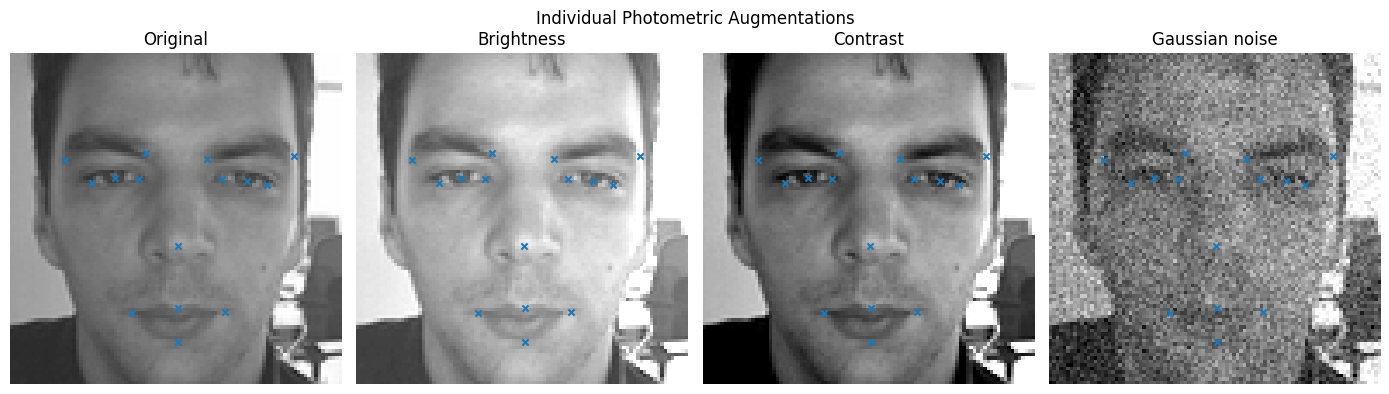

In [ ]:
# Visualize individual photometric augmentations for reporting

def plot_individual_photometric_augmentations(
    dataframe,
    sample_index=0,
    save_path=None
):
    row = dataframe.iloc[sample_index]

    original_image = image_string_to_array(row["Image"]) / 255.0
    original_image = original_image.astype(np.float32)

    keypoints = row[KEYPOINT_COLUMNS].values.astype(np.float32).reshape(-1, 2)
    valid_keypoints = ~np.isnan(keypoints).any(axis=1)

    brightness_image = apply_brightness(
        original_image.copy(),
        brightness_range=(1.45, 1.45)
    )

    contrast_image = apply_contrast(
        original_image.copy(),
        contrast_range=(1.65, 1.65)
    )

    noise_image = apply_gaussian_noise(
        original_image.copy(),
        noise_std_range=(0.08, 0.08)
    )

    images_to_plot = [
        original_image,
        brightness_image,
        contrast_image,
        noise_image
    ]

    titles = [
        "Original",
        "Brightness",
        "Contrast",
        "Gaussian noise"
    ]

    plt.figure(figsize=(14, 4))

    for i, image in enumerate(images_to_plot):
        plt.subplot(1, 4, i + 1)
        plt.imshow(image, cmap="gray", vmin=0, vmax=1)
        plt.scatter(
            keypoints[valid_keypoints, 0],
            keypoints[valid_keypoints, 1],
            s=20,
            marker="x"
        )
        plt.title(titles[i])
        plt.axis("off")

    plt.suptitle("Individual Photometric Augmentations")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)

    plt.show()


complete_train_indices = train_model_df.index[train_model_df["is_complete"] == 1].tolist()
sample_index = complete_train_indices[0]

plot_individual_photometric_augmentations(
    train_model_df,
    sample_index=sample_index,
    save_path=PLOTS_DIR / "individual_photometric_augmentations.png"
)

Running experiment: cnn_complex_aug_adam_mse_lr5e4
Epoch 001/40 | Train Loss: 0.02501 | Val Loss: 0.02478 | Train RMSE: 15.1831 | Val RMSE: 15.1126 | Train NME: 0.5544 | Val NME: 0.5471
Epoch 002/40 | Train Loss: 0.00548 | Val Loss: 0.00501 | Train RMSE: 7.1044 | Val RMSE: 6.7893 | Train NME: 0.2400 | Val NME: 0.2254
Epoch 003/40 | Train Loss: 0.00785 | Val Loss: 0.00763 | Train RMSE: 8.4965 | Val RMSE: 8.3796 | Train NME: 0.2980 | Val NME: 0.2898
Epoch 004/40 | Train Loss: 0.00937 | Val Loss: 0.00902 | Train RMSE: 9.2893 | Val RMSE: 9.1140 | Train NME: 0.3299 | Val NME: 0.3193
Epoch 005/40 | Train Loss: 0.01348 | Val Loss: 0.01278 | Train RMSE: 11.1443 | Val RMSE: 10.8513 | Train NME: 0.4099 | Val NME: 0.3947
Epoch 006/40 | Train Loss: 0.01394 | Val Loss: 0.01394 | Train RMSE: 11.3284 | Val RMSE: 11.3336 | Train NME: 0.4193 | Val NME: 0.4138
Epoch 007/40 | Train Loss: 0.02668 | Val Loss: 0.02649 | Train RMSE: 15.6781 | Val RMSE: 15.6226 | Train NME: 0.5902 | Val NME: 0.5823
Epoch 008/

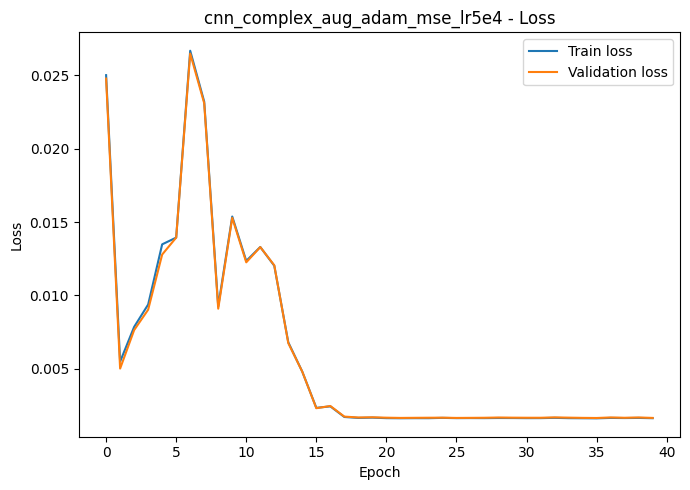

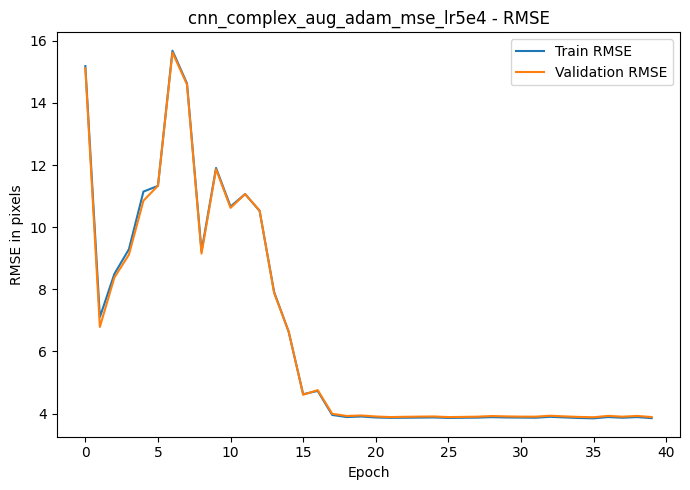

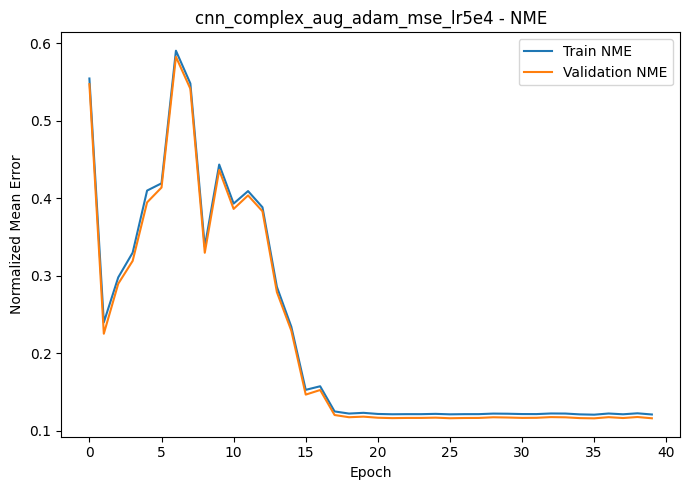

,model,architecture,optimizer,loss,rmse,mae,normalized_mean_error,experiment_name
0,mean_keypoint_baseline,constant_mean_prediction,none,none,3.907841,2.648260,0.116925,NaN
1,mlp,"(256, 128)",adam,masked_mse,3.791402,2.566219,0.112872,mlp_smaller_adam_mse
2,mlp,"(1024, 512, 256)",adam,masked_mse,3.911745,2.652725,0.117171,mlp_large_dropout_adam_mse
3,mlp,"(512, 256, 128)",adam,masked_smooth_l1,3.915837,2.659091,0.117211,mlp_adam_smooth_l1
4,mlp,"(512, 256, 128)",sgd,masked_mse,3.753970,2.527895,0.111361,mlp_sgd_mse
5,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.773986,2.561119,0.112581,cnn_simple_adam_mse
6,cnn,"simple | conv=(16, 32, 64) | dense=(128,)",adam,masked_mse,3.481961,2.309657,0.101834,cnn_simple_smaller_adam_mse
7,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.868397,2.629376,0.115810,cnn_simple_dropout_adam_mse
8,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_smooth_l1,3.250028,2.123828,0.093494,cnn_simple_smooth_l1
9,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",sgd,masked_mse,4.008184,2.774023,0.121907,cnn_simple_sgd_mse


Final test metrics:
{'rmse': 3.806368112564087, 'mae': 2.6370723247528076, 'nme': 0.11882205307483673, 'loss': 0.0015795569595535139}
Running experiment: cnn_complex_aug_adam_smooth_l1_lr5e4
Epoch 001/40 | Train Loss: 0.00729 | Val Loss: 0.00732 | Train RMSE: 11.5990 | Val RMSE: 11.6208 | Train NME: 0.4194 | Val NME: 0.4154
Epoch 002/40 | Train Loss: 0.01331 | Val Loss: 0.01305 | Train RMSE: 15.6606 | Val RMSE: 15.5026 | Train NME: 0.5780 | Val NME: 0.5677
Epoch 003/40 | Train Loss: 0.00698 | Val Loss: 0.00683 | Train RMSE: 11.3429 | Val RMSE: 11.2184 | Train NME: 0.4179 | Val NME: 0.4074
Epoch 004/40 | Train Loss: 0.01098 | Val Loss: 0.01079 | Train RMSE: 14.2186 | Val RMSE: 14.0972 | Train NME: 0.5281 | Val NME: 0.5188
Epoch 005/40 | Train Loss: 0.01153 | Val Loss: 0.01153 | Train RMSE: 14.5758 | Val RMSE: 14.5726 | Train NME: 0.5429 | Val NME: 0.5371
Epoch 006/40 | Train Loss: 0.00612 | Val Loss: 0.00596 | Train RMSE: 10.6291 | Val RMSE: 10.4794 | Train NME: 0.3829 | Val NME: 0.3732

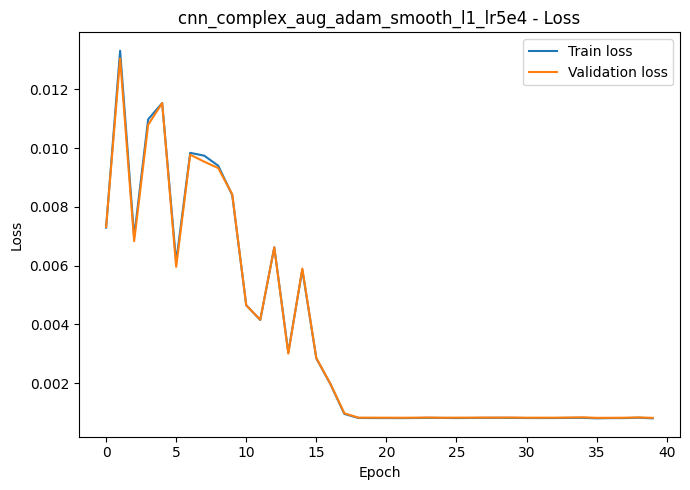

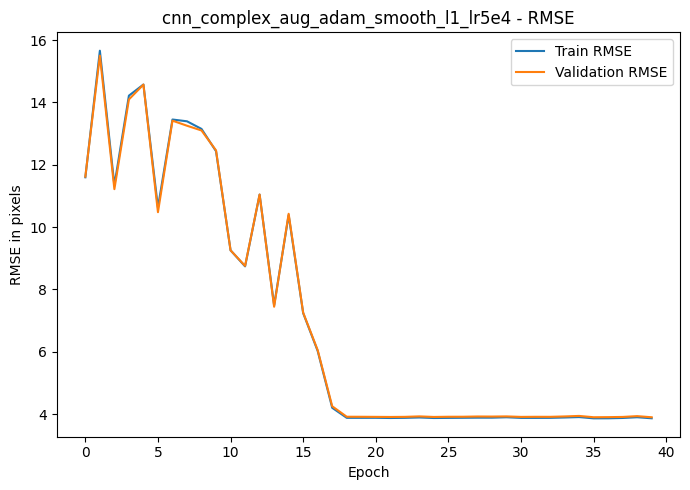

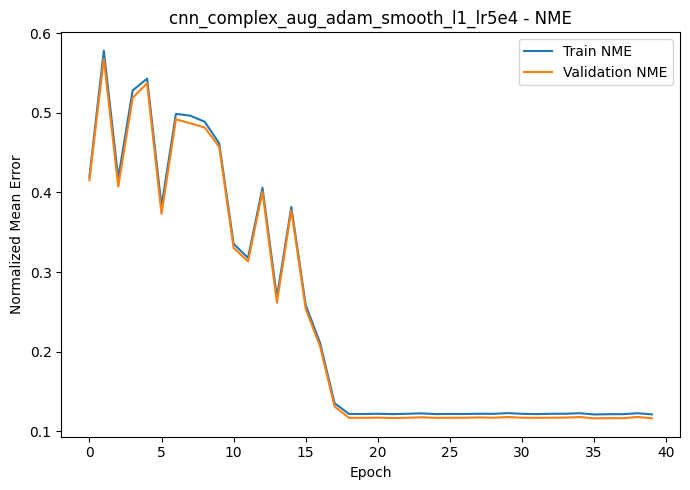

,model,architecture,optimizer,loss,rmse,mae,normalized_mean_error,experiment_name
0,mean_keypoint_baseline,constant_mean_prediction,none,none,3.907841,2.648260,0.116925,NaN
1,mlp,"(256, 128)",adam,masked_mse,3.791402,2.566219,0.112872,mlp_smaller_adam_mse
2,mlp,"(1024, 512, 256)",adam,masked_mse,3.911745,2.652725,0.117171,mlp_large_dropout_adam_mse
3,mlp,"(512, 256, 128)",adam,masked_smooth_l1,3.915837,2.659091,0.117211,mlp_adam_smooth_l1
4,mlp,"(512, 256, 128)",sgd,masked_mse,3.753970,2.527895,0.111361,mlp_sgd_mse
5,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.773986,2.561119,0.112581,cnn_simple_adam_mse
6,cnn,"simple | conv=(16, 32, 64) | dense=(128,)",adam,masked_mse,3.481961,2.309657,0.101834,cnn_simple_smaller_adam_mse
7,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.868397,2.629376,0.115810,cnn_simple_dropout_adam_mse
8,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_smooth_l1,3.250028,2.123828,0.093494,cnn_simple_smooth_l1
9,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",sgd,masked_mse,4.008184,2.774023,0.121907,cnn_simple_sgd_mse


Final test metrics:
{'rmse': 3.833930492401123, 'mae': 2.654432535171509, 'nme': 0.1196182370185852, 'loss': 0.0008012679833192246}
Running experiment: cnn_complex_aug_adam_mse_lr3e4
Epoch 001/50 | Train Loss: 0.01770 | Val Loss: 0.01553 | Train RMSE: 12.7718 | Val RMSE: 11.9631 | Train NME: 0.4511 | Val NME: 0.4190
Epoch 002/50 | Train Loss: 0.00792 | Val Loss: 0.00761 | Train RMSE: 8.5372 | Val RMSE: 8.3829 | Train NME: 0.3021 | Val NME: 0.2928
Epoch 003/50 | Train Loss: 0.01370 | Val Loss: 0.01313 | Train RMSE: 11.2270 | Val RMSE: 10.9998 | Train NME: 0.4098 | Val NME: 0.3974
Epoch 004/50 | Train Loss: 0.01625 | Val Loss: 0.01620 | Train RMSE: 12.2318 | Val RMSE: 12.2184 | Train NME: 0.4565 | Val NME: 0.4504
Epoch 005/50 | Train Loss: 0.01484 | Val Loss: 0.01441 | Train RMSE: 11.6872 | Val RMSE: 11.5141 | Train NME: 0.4294 | Val NME: 0.4185
Epoch 006/50 | Train Loss: 0.01218 | Val Loss: 0.01224 | Train RMSE: 10.5910 | Val RMSE: 10.6167 | Train NME: 0.3953 | Val NME: 0.3909
Epoch 007

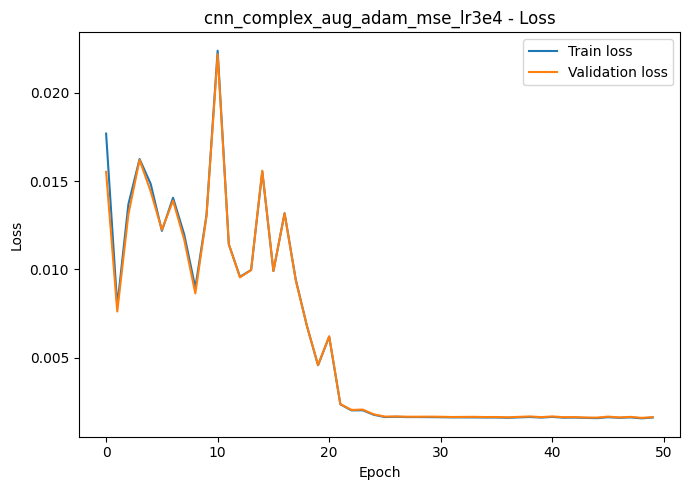

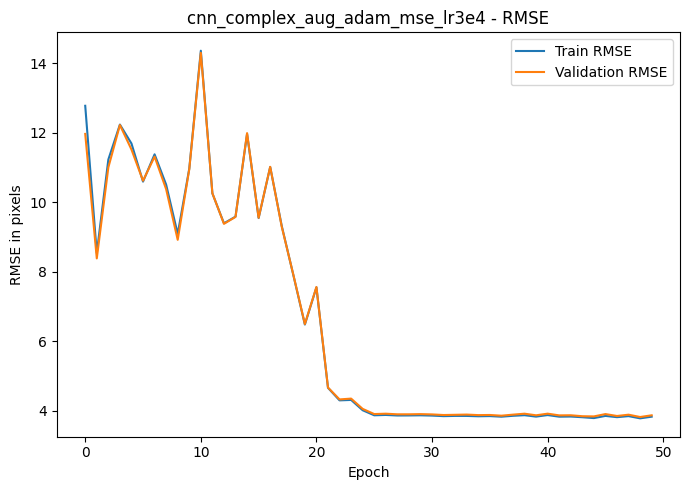

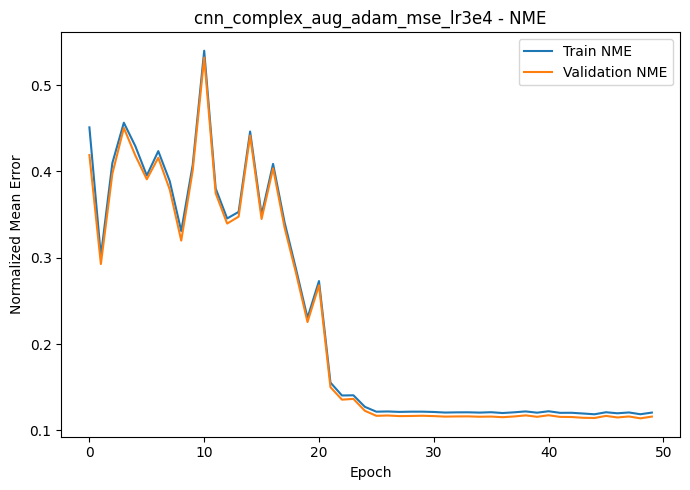

,model,architecture,optimizer,loss,rmse,mae,normalized_mean_error,experiment_name
0,mean_keypoint_baseline,constant_mean_prediction,none,none,3.907841,2.648260,0.116925,NaN
1,mlp,"(256, 128)",adam,masked_mse,3.791402,2.566219,0.112872,mlp_smaller_adam_mse
2,mlp,"(1024, 512, 256)",adam,masked_mse,3.911745,2.652725,0.117171,mlp_large_dropout_adam_mse
3,mlp,"(512, 256, 128)",adam,masked_smooth_l1,3.915837,2.659091,0.117211,mlp_adam_smooth_l1
4,mlp,"(512, 256, 128)",sgd,masked_mse,3.753970,2.527895,0.111361,mlp_sgd_mse
5,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.773986,2.561119,0.112581,cnn_simple_adam_mse
6,cnn,"simple | conv=(16, 32, 64) | dense=(128,)",adam,masked_mse,3.481961,2.309657,0.101834,cnn_simple_smaller_adam_mse
7,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.868397,2.629376,0.115810,cnn_simple_dropout_adam_mse
8,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_smooth_l1,3.250028,2.123828,0.093494,cnn_simple_smooth_l1
9,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",sgd,masked_mse,4.008184,2.774023,0.121907,cnn_simple_sgd_mse


Final test metrics:
{'rmse': 3.7423696517944336, 'mae': 2.5870025157928467, 'nme': 0.1165754497051239, 'loss': 0.0015264836249511962}
Running experiment: cnn_medium_aug_adam_mse_lr5e4
Epoch 001/40 | Train Loss: 0.01789 | Val Loss: 0.01747 | Train RMSE: 12.8422 | Val RMSE: 12.6953 | Train NME: 0.4711 | Val NME: 0.4606
Epoch 002/40 | Train Loss: 0.02095 | Val Loss: 0.02066 | Train RMSE: 13.8920 | Val RMSE: 13.8052 | Train NME: 0.5057 | Val NME: 0.4968
Epoch 003/40 | Train Loss: 0.01474 | Val Loss: 0.01410 | Train RMSE: 11.6509 | Val RMSE: 11.3978 | Train NME: 0.4255 | Val NME: 0.4117
Epoch 004/40 | Train Loss: 0.00859 | Val Loss: 0.00824 | Train RMSE: 8.8875 | Val RMSE: 8.7170 | Train NME: 0.3216 | Val NME: 0.3103
Epoch 005/40 | Train Loss: 0.02037 | Val Loss: 0.02037 | Train RMSE: 13.6950 | Val RMSE: 13.6954 | Train NME: 0.5078 | Val NME: 0.5026
Epoch 006/40 | Train Loss: 0.00688 | Val Loss: 0.00675 | Train RMSE: 7.9549 | Val RMSE: 7.8890 | Train NME: 0.2809 | Val NME: 0.2725
Epoch 007/

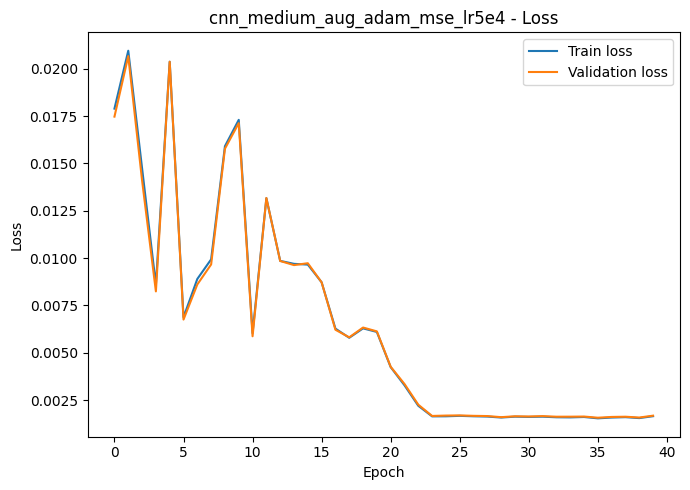

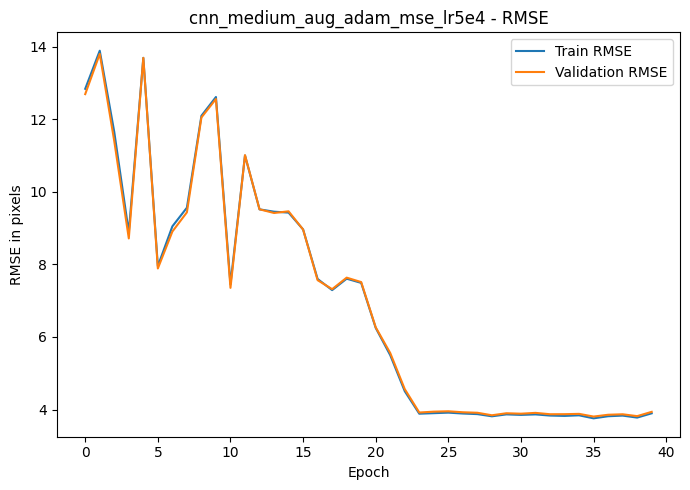

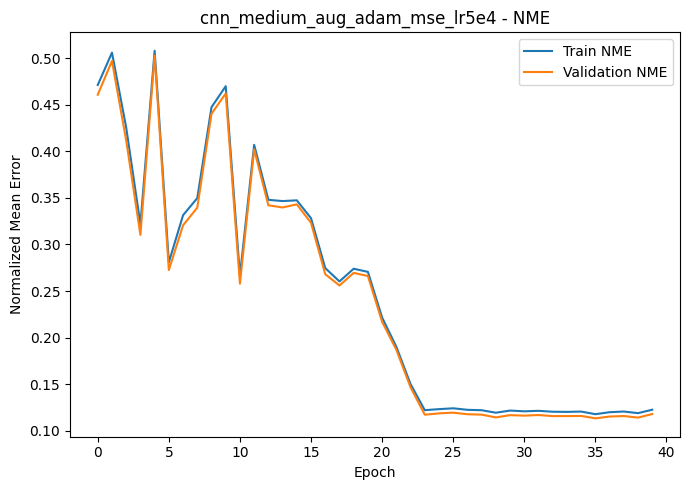

,model,architecture,optimizer,loss,rmse,mae,normalized_mean_error,experiment_name
0,mean_keypoint_baseline,constant_mean_prediction,none,none,3.907841,2.648260,0.116925,NaN
1,mlp,"(256, 128)",adam,masked_mse,3.791402,2.566219,0.112872,mlp_smaller_adam_mse
2,mlp,"(1024, 512, 256)",adam,masked_mse,3.911745,2.652725,0.117171,mlp_large_dropout_adam_mse
3,mlp,"(512, 256, 128)",adam,masked_smooth_l1,3.915837,2.659091,0.117211,mlp_adam_smooth_l1
4,mlp,"(512, 256, 128)",sgd,masked_mse,3.753970,2.527895,0.111361,mlp_sgd_mse
5,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.773986,2.561119,0.112581,cnn_simple_adam_mse
6,cnn,"simple | conv=(16, 32, 64) | dense=(128,)",adam,masked_mse,3.481961,2.309657,0.101834,cnn_simple_smaller_adam_mse
7,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.868397,2.629376,0.115810,cnn_simple_dropout_adam_mse
8,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_smooth_l1,3.250028,2.123828,0.093494,cnn_simple_smooth_l1
9,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",sgd,masked_mse,4.008184,2.774023,0.121907,cnn_simple_sgd_mse


Final test metrics:
{'rmse': 3.723750591278076, 'mae': 2.575275182723999, 'nme': 0.11582440882921219, 'loss': 0.0015116146951143236}
Running experiment: cnn_complex_aug_rmsprop_mse_lr5e4
Epoch 001/40 | Train Loss: 0.03817 | Val Loss: 0.03764 | Train RMSE: 18.7516 | Val RMSE: 18.6218 | Train NME: 0.6954 | Val NME: 0.6815
Epoch 002/40 | Train Loss: 0.03006 | Val Loss: 0.02971 | Train RMSE: 16.6355 | Val RMSE: 16.5417 | Train NME: 0.6115 | Val NME: 0.6012
Epoch 003/40 | Train Loss: 0.02113 | Val Loss: 0.02069 | Train RMSE: 13.9389 | Val RMSE: 13.7946 | Train NME: 0.5032 | Val NME: 0.4934
Epoch 004/40 | Train Loss: 0.06424 | Val Loss: 0.06373 | Train RMSE: 24.3141 | Val RMSE: 24.2238 | Train NME: 0.9182 | Val NME: 0.9090
Epoch 005/40 | Train Loss: 0.02478 | Val Loss: 0.02446 | Train RMSE: 15.1035 | Val RMSE: 15.0043 | Train NME: 0.5609 | Val NME: 0.5523
Epoch 006/40 | Train Loss: 0.02192 | Val Loss: 0.02162 | Train RMSE: 14.2115 | Val RMSE: 14.1109 | Train NME: 0.5266 | Val NME: 0.5172
Epo

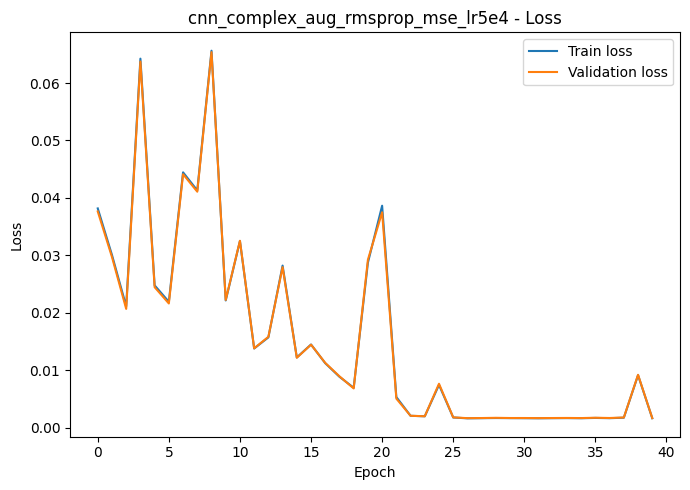

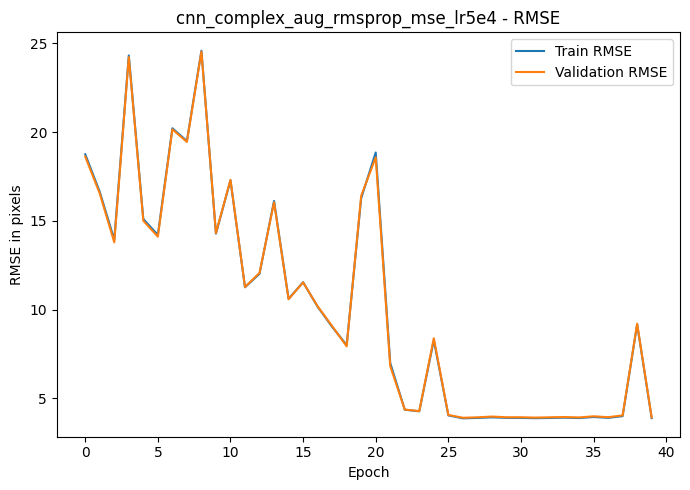

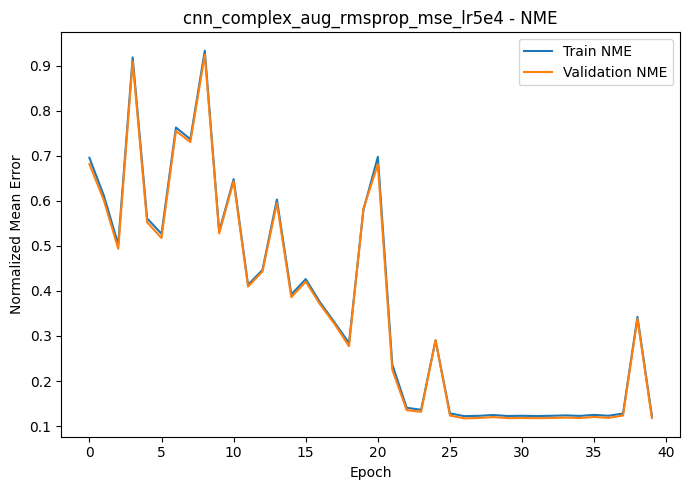

,model,architecture,optimizer,loss,rmse,mae,normalized_mean_error,experiment_name
0,mean_keypoint_baseline,constant_mean_prediction,none,none,3.907841,2.648260,0.116925,NaN
1,mlp,"(256, 128)",adam,masked_mse,3.791402,2.566219,0.112872,mlp_smaller_adam_mse
2,mlp,"(1024, 512, 256)",adam,masked_mse,3.911745,2.652725,0.117171,mlp_large_dropout_adam_mse
3,mlp,"(512, 256, 128)",adam,masked_smooth_l1,3.915837,2.659091,0.117211,mlp_adam_smooth_l1
4,mlp,"(512, 256, 128)",sgd,masked_mse,3.753970,2.527895,0.111361,mlp_sgd_mse
5,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.773986,2.561119,0.112581,cnn_simple_adam_mse
6,cnn,"simple | conv=(16, 32, 64) | dense=(128,)",adam,masked_mse,3.481961,2.309657,0.101834,cnn_simple_smaller_adam_mse
7,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_mse,3.868397,2.629376,0.115810,cnn_simple_dropout_adam_mse
8,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",adam,masked_smooth_l1,3.250028,2.123828,0.093494,cnn_simple_smooth_l1
9,cnn,"simple | conv=(32, 64, 128) | dense=(256,)",sgd,masked_mse,4.008184,2.774023,0.121907,cnn_simple_sgd_mse


Final test metrics:
{'rmse': 3.838216543197632, 'mae': 2.665172576904297, 'nme': 0.11996468901634216, 'loss': 0.001605969662425806}


In [ ]:
# Run the selected regularized and augmented CNN experiments

cnn_complex_experiments = [
    {
        "experiment_name": "cnn_complex_aug_adam_mse_lr5e4",
        "model_family": "cnn_augmented",
        "model_size": "complex",
        "conv_channels": (32, 64, 128, 256),
        "dense_layers": (512, 256),
        "dropout": 0.3,
        "use_batch_norm": True,
        "activation": "relu",
        "batch_size": 64,
        "epochs": 40,
        "optimizer": "adam",
        "learning_rate": 5e-4,
        "weight_decay": 1e-5,
        "loss_function": "masked_mse"
    },
    {
        "experiment_name": "cnn_complex_aug_adam_smooth_l1_lr5e4",
        "model_family": "cnn_augmented",
        "model_size": "complex",
        "conv_channels": (32, 64, 128, 256),
        "dense_layers": (512, 256),
        "dropout": 0.3,
        "use_batch_norm": True,
        "activation": "relu",
        "batch_size": 64,
        "epochs": 40,
        "optimizer": "adam",
        "learning_rate": 5e-4,
        "weight_decay": 1e-5,
        "loss_function": "masked_smooth_l1"
    },
    {
        "experiment_name": "cnn_complex_aug_adam_mse_lr3e4",
        "model_family": "cnn_augmented",
        "model_size": "complex",
        "conv_channels": (32, 64, 128, 256),
        "dense_layers": (512, 256),
        "dropout": 0.3,
        "use_batch_norm": True,
        "activation": "relu",
        "batch_size": 64,
        "epochs": 50,
        "optimizer": "adam",
        "learning_rate": 3e-4,
        "weight_decay": 1e-5,
        "loss_function": "masked_mse"
    },
    {
        "experiment_name": "cnn_medium_aug_adam_mse_lr5e4",
        "model_family": "cnn_augmented",
        "model_size": "complex",
        "conv_channels": (32, 64, 128),
        "dense_layers": (512, 256),
        "dropout": 0.25,
        "use_batch_norm": True,
        "activation": "relu",
        "batch_size": 64,
        "epochs": 40,
        "optimizer": "adam",
        "learning_rate": 5e-4,
        "weight_decay": 1e-5,
        "loss_function": "masked_mse"
    },
    {
        "experiment_name": "cnn_complex_aug_rmsprop_mse_lr5e4",
        "model_family": "cnn_augmented",
        "model_size": "complex",
        "conv_channels": (32, 64, 128, 256),
        "dense_layers": (512, 256),
        "dropout": 0.3,
        "use_batch_norm": True,
        "activation": "relu",
        "batch_size": 64,
        "epochs": 40,
        "optimizer": "rmsprop",
        "learning_rate": 5e-4,
        "weight_decay": 1e-5,
        "loss_function": "masked_mse"
    }
]

cnn_complex_outputs = {}

for config in cnn_complex_experiments:
    config["architecture_label"] = (
        f"{config['model_size']} | "
        f"conv={config['conv_channels']} | "
        f"dense={config['dense_layers']} | "
        f"batch_norm={config['use_batch_norm']} | "
        f"dropout={config['dropout']}"
    )

    model_kwargs = {
        "input_channels": 1,
        "output_dim": len(KEYPOINT_COLUMNS),
        "model_size": config["model_size"],
        "conv_channels": config["conv_channels"],
        "dense_layers": config["dense_layers"],
        "dropout": config["dropout"],
        "use_batch_norm": config["use_batch_norm"],
        "activation": config["activation"]
    }

    trained_model, history_df, test_metrics, summary_df = run_experiment(
        config=config,
        model_class=ConfigurableCNN,
        model_kwargs=model_kwargs,
        image_mode="cnn",
        augment_train=True
    )

    cnn_complex_outputs[config["experiment_name"]] = {
        "model": trained_model,
        "history": history_df,
        "test_metrics": test_metrics,
        "summary": summary_df
    }

**Section 8 - Transfer Learning from YKFK .h5 to FKD**

In [ ]:
# Load the pretrained YKFK .h5 model with compatibility fixes for older Keras DepthwiseConv2D configs

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Dropout, DepthwiseConv2D
from tensorflow.keras.optimizers import Adam

class CompatibleDepthwiseConv2D(DepthwiseConv2D):
    def __init__(self, *args, **kwargs):
        kwargs.pop("groups", None)
        super().__init__(*args, **kwargs)

# Adapt the path to download the model
YKFK_MODEL_PATH = Path("facial_model.h5")

if not YKFK_MODEL_PATH.exists():
    raise FileNotFoundError(f"Model file not found: {YKFK_MODEL_PATH}")

ykfk_model = load_model(
    YKFK_MODEL_PATH,
    compile=False,
    custom_objects={
        "DepthwiseConv2D": CompatibleDepthwiseConv2D
    }
)

print("YKFK model loaded successfully.")
print("Input shape:", ykfk_model.input_shape)
print("Output shape:", ykfk_model.output_shape)

ykfk_model.summary()

YKFK model loaded successfully.
Input shape: (None, None, None, 3)
Output shape: (None, 68, 3)


Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_1             │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, None,      │        864 │ input_1[0][0]     │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, None,      │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, None,      │          0 │ bn_Conv1[0][0]    │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │        288 │ Conv1_relu[0][0]  │
│ (CompatibleDepthwi… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │          0 │ expanded_conv_de… │
│ (ReLU)              │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │        512 │ expanded_conv_de… │
│ (Conv2D)            │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, None,      │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, None,      │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, None,      │          0 │ block_1_expand_B… │
│ (ReLU)              │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, None,      │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, None,      │        864 │ block_1_pad[0][0] │
│ (CompatibleDepthwi… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, None,      │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, None,      │          0 │ block_1_depthwis… │
│ (ReLU)              │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, None,      │      2,304 │ block_1_depthwis

 Total params: 12,873,508 (49.11 MB)

 Trainable params: 12,828,692 (48.94 MB)

 Non-trainable params: 44,816 (175.06 KB)

In [ ]:
# Prepare FKD images, targets, and masks for transfer learning with fixed RGB input size

TRANSFER_IMAGE_SIZE = 150
TRANSFER_CHANNELS = 3

def fkd_image_to_transfer_input(image_string, image_size=TRANSFER_IMAGE_SIZE):
    image = image_string_to_array(image_string) / 255.0
    image = image.astype(np.float32)
    image = image[..., np.newaxis]

    image = tf.image.resize(
        image,
        size=tf.constant([image_size, image_size], dtype=tf.int32)
    ).numpy()

    image = np.repeat(image, 3, axis=-1)

    return image.astype(np.float32)


def prepare_transfer_targets_and_masks(dataframe, keypoint_columns, target_fill_values):
    targets = dataframe[keypoint_columns].copy()
    masks = (~targets.isna()).astype(np.float32).values

    targets = targets.fillna(target_fill_values)
    targets = targets.values.astype(np.float32)
    targets = targets / 96.0

    y_combined = np.concatenate([targets, masks], axis=1)

    return targets, masks, y_combined


X_train_transfer = np.stack([
    fkd_image_to_transfer_input(img)
    for img in train_model_df["Image"]
])

X_val_transfer = np.stack([
    fkd_image_to_transfer_input(img)
    for img in val_model_df["Image"]
])

X_test_transfer = np.stack([
    fkd_image_to_transfer_input(img)
    for img in test_model_df["Image"]
])

y_train_transfer, mask_train_transfer, y_train_transfer_combined = prepare_transfer_targets_and_masks(
    train_model_df,
    KEYPOINT_COLUMNS,
    target_fill_values
)

y_val_transfer, mask_val_transfer, y_val_transfer_combined = prepare_transfer_targets_and_masks(
    val_model_df,
    KEYPOINT_COLUMNS,
    target_fill_values
)

y_test_transfer, mask_test_transfer, y_test_transfer_combined = prepare_transfer_targets_and_masks(
    test_model_df,
    KEYPOINT_COLUMNS,
    target_fill_values
)

print("Transfer learning data prepared.")
print("X train shape:", X_train_transfer.shape)
print("X validation shape:", X_val_transfer.shape)
print("X test shape:", X_test_transfer.shape)
print("Y train combined shape:", y_train_transfer_combined.shape)

Transfer learning data prepared.
X train shape: (4793, 150, 150, 3)
X validation shape: (1410, 150, 150, 3)
X test shape: (846, 150, 150, 3)
Y train combined shape: (4793, 60)


In [ ]:
# Build a FKD transfer-learning model by replacing the YKFK 68x3 output head with a 30-coordinate head

from tensorflow.keras.layers import GlobalAveragePooling2D

def find_global_average_pooling_layer(model):
    for layer in model.layers:
        if isinstance(layer, GlobalAveragePooling2D):
            return layer

    raise ValueError("No GlobalAveragePooling2D layer found in the pretrained model.")


feature_layer = find_global_average_pooling_layer(ykfk_model)

print("Selected feature layer:", feature_layer.name)
print("Selected feature layer output shape:", feature_layer.output.shape)

feature_extractor = Model(
    inputs=ykfk_model.input,
    outputs=feature_layer.output,
    name="ykfk_feature_extractor"
)

feature_extractor.trainable = False

x = feature_extractor.output
x = Dense(512, activation="relu", name="fkd_dense_512")(x)
x = Dropout(0.2, name="fkd_dropout_1")(x)
x = Dense(256, activation="relu", name="fkd_dense_256")(x)
x = Dropout(0.2, name="fkd_dropout_2")(x)
outputs = Dense(len(KEYPOINT_COLUMNS), activation="linear", name="fkd_keypoints")(x)

fkd_transfer_model = Model(
    inputs=feature_extractor.input,
    outputs=outputs,
    name="fkd_transfer_model"
)

fkd_transfer_model.summary()

Selected feature layer: global_average_pooling2d
Selected feature layer output shape: (None, 1280)


Model: "fkd_transfer_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_1             │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, None,      │        864 │ input_1[0][0]     │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, None,      │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, None,      │          0 │ bn_Conv1[0][0]    │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │        288 │ Conv1_relu[0][0]  │
│ (CompatibleDepthwi… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │          0 │ expanded_conv_de… │
│ (ReLU)              │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │        512 │ expanded_conv_de… │
│ (Conv2D)            │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, None,      │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, None,      │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, None,      │          0 │ block_1_expand_B… │
│ (ReLU)              │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, None,      │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, None,      │        864 │ block_1_pad[0][0] │
│ (CompatibleDepthwi… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, None,      │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, None,      │          0 │ block_1_depthwis… │
│ (ReLU)              │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, None,      │      2,304 │ block_1_depthwis

 Total params: 3,052,894 (11.65 MB)

 Trainable params: 794,910 (3.03 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Define masked Keras losses, NumPy NME metrics, epoch metric callback, and transfer-learning plots

def masked_mse_keras(y_true_combined, y_pred):
    y_true = y_true_combined[:, :len(KEYPOINT_COLUMNS)]
    mask = y_true_combined[:, len(KEYPOINT_COLUMNS):]

    squared_error = tf.square(y_pred - y_true)
    masked_error = squared_error * mask

    return tf.reduce_sum(masked_error) / tf.maximum(tf.reduce_sum(mask), 1.0)


def masked_smooth_l1_keras(y_true_combined, y_pred):
    y_true = y_true_combined[:, :len(KEYPOINT_COLUMNS)]
    mask = y_true_combined[:, len(KEYPOINT_COLUMNS):]

    error = tf.abs(y_pred - y_true)
    smooth_l1 = tf.where(error < 1.0, 0.5 * tf.square(error), error - 0.5)
    masked_error = smooth_l1 * mask

    return tf.reduce_sum(masked_error) / tf.maximum(tf.reduce_sum(mask), 1.0)


def compute_transfer_metrics_numpy(y_true, y_pred, mask):
    y_true_px = y_true * 96.0
    y_pred_px = y_pred * 96.0

    valid = mask == 1

    rmse = np.sqrt(np.mean((y_pred_px[valid] - y_true_px[valid]) ** 2))
    mae = np.mean(np.abs(y_pred_px[valid] - y_true_px[valid]))

    y_true_points = y_true_px.reshape(-1, 15, 2)
    y_pred_points = y_pred_px.reshape(-1, 15, 2)
    mask_points = mask.reshape(-1, 15, 2)

    valid_points = mask_points.all(axis=2)

    left_eye_idx = KEYPOINT_COLUMNS.index("left_eye_center_x") // 2
    right_eye_idx = KEYPOINT_COLUMNS.index("right_eye_center_x") // 2

    left_eye_valid = valid_points[:, left_eye_idx]
    right_eye_valid = valid_points[:, right_eye_idx]

    interocular_distance = np.sqrt(
        np.sum(
            (y_true_points[:, left_eye_idx, :] - y_true_points[:, right_eye_idx, :]) ** 2,
            axis=1
        )
    )

    valid_normalizer = left_eye_valid & right_eye_valid & (interocular_distance > 1e-6)

    distances = np.sqrt(np.sum((y_pred_points - y_true_points) ** 2, axis=2))
    valid_for_nme = valid_points & valid_normalizer[:, None]

    if valid_for_nme.sum() > 0:
        normalized_errors = distances[valid_for_nme] / np.repeat(
            interocular_distance[:, None],
            repeats=15,
            axis=1
        )[valid_for_nme]
        nme = np.mean(normalized_errors)
    else:
        nme = np.nan

    return {
        "rmse": rmse,
        "mae": mae,
        "nme": nme
    }


class TransferMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(
        self,
        X_train,
        y_train,
        mask_train,
        X_val,
        y_val,
        mask_val,
        batch_size=64
    ):
        super().__init__()
        self.X_train = X_train
        self.y_train = y_train
        self.mask_train = mask_train
        self.X_val = X_val
        self.y_val = y_val
        self.mask_val = mask_val
        self.batch_size = batch_size
        self.history = {
            "train_rmse": [],
            "val_rmse": [],
            "train_mae": [],
            "val_mae": [],
            "train_nme": [],
            "val_nme": []
        }

    def on_epoch_end(self, epoch, logs=None):
        train_pred = self.model.predict(
            self.X_train,
            batch_size=self.batch_size,
            verbose=0
        )

        val_pred = self.model.predict(
            self.X_val,
            batch_size=self.batch_size,
            verbose=0
        )

        train_metrics = compute_transfer_metrics_numpy(
            self.y_train,
            train_pred,
            self.mask_train
        )

        val_metrics = compute_transfer_metrics_numpy(
            self.y_val,
            val_pred,
            self.mask_val
        )

        self.history["train_rmse"].append(train_metrics["rmse"])
        self.history["val_rmse"].append(val_metrics["rmse"])
        self.history["train_mae"].append(train_metrics["mae"])
        self.history["val_mae"].append(val_metrics["mae"])
        self.history["train_nme"].append(train_metrics["nme"])
        self.history["val_nme"].append(val_metrics["nme"])

        print(
            f" | Train RMSE: {train_metrics['rmse']:.4f}"
            f" | Val RMSE: {val_metrics['rmse']:.4f}"
            f" | Train NME: {train_metrics['nme']:.4f}"
            f" | Val NME: {val_metrics['nme']:.4f}"
        )


def build_transfer_history_df(keras_history, metrics_callback):
    history_df = pd.DataFrame(keras_history.history)

    for key, values in metrics_callback.history.items():
        history_df[key] = values

    history_df = history_df.rename(
        columns={
            "loss": "train_loss",
            "val_loss": "val_loss"
        }
    )

    return history_df


def plot_transfer_training_history(history_df, experiment_name):
    plt.figure(figsize=(7, 5))
    plt.plot(history_df["train_loss"], label="Train loss")
    plt.plot(history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{experiment_name} - Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{experiment_name}_loss.png", dpi=150)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history_df["train_rmse"], label="Train RMSE")
    plt.plot(history_df["val_rmse"], label="Validation RMSE")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE in pixels")
    plt.title(f"{experiment_name} - RMSE")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{experiment_name}_rmse.png", dpi=150)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history_df["train_nme"], label="Train NME")
    plt.plot(history_df["val_nme"], label="Validation NME")
    plt.xlabel("Epoch")
    plt.ylabel("Normalized Mean Error")
    plt.title(f"{experiment_name} - NME")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{experiment_name}_nme.png", dpi=150)
    plt.show()

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - loss: 0.1599 | Train RMSE: 9.7065 | Val RMSE: 9.9390 | Train NME: 0.3211 | Val NME: 0.3198
75/75 ━━━━━━━━━━━━━━━━━━━━ 82s 792ms/step - loss: 0.0680 - val_loss: 0.0107
Epoch 2/20
73/75 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0163 | Train RMSE: 5.5764 | Val RMSE: 5.8040 | Train NME: 0.1815 | Val NME: 0.1806
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - loss: 0.0138 - val_loss: 0.0036
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0087 | Train RMSE: 4.7901 | Val RMSE: 4.9087 | Train NME: 0.1567 | Val NME: 0.1548
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - loss: 0.0082 - val_loss: 0.0026
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0066 | Train RMSE: 4.8785 | Val RMSE: 4.9392 | Train NME: 0.1625 | Val NME: 0.1594
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - loss: 0.0063 - val_loss: 0.0026
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0055 | Train RMSE: 4.1920 | Val RMSE: 4.2069 | Train NME: 0.1

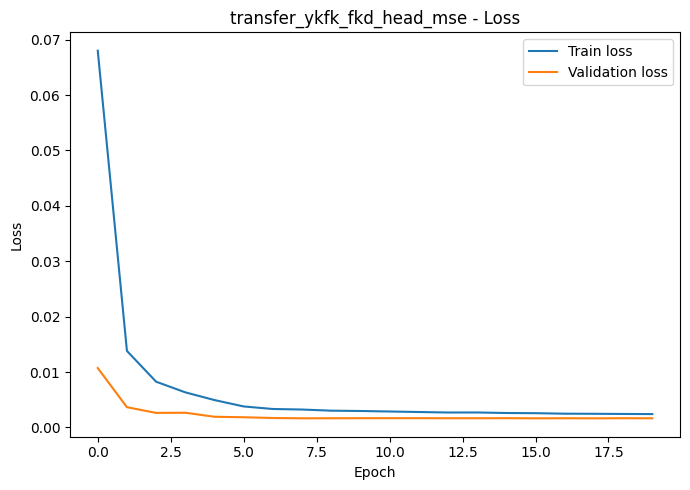

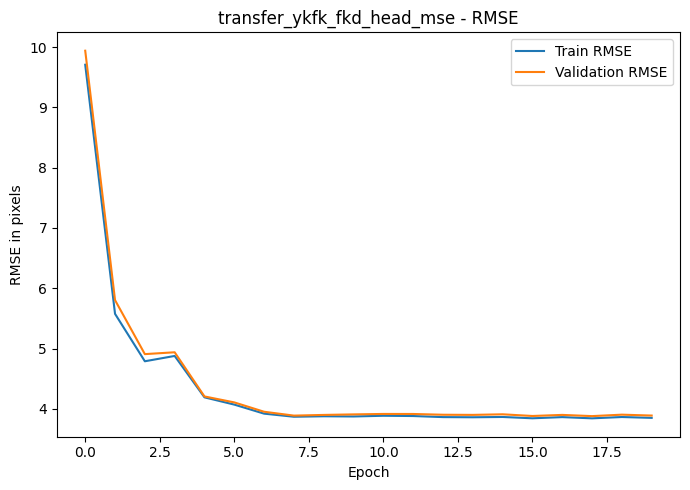

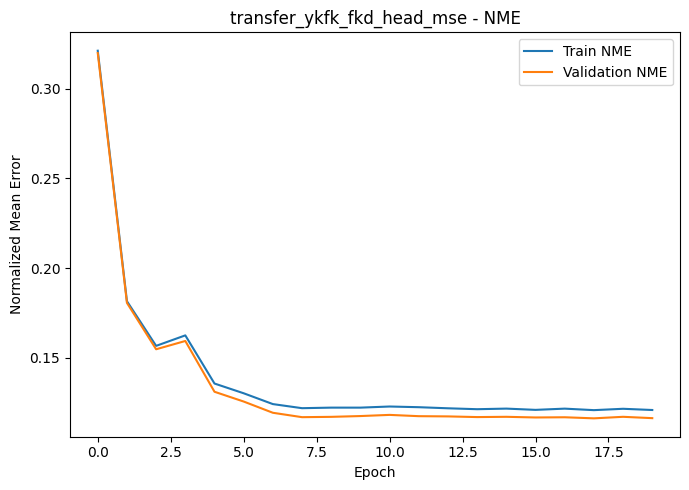

Transfer head training completed.


In [ ]:
# Train only the new FKD regression head while keeping the YKFK feature extractor frozen

transfer_head_config = {
    "experiment_name": "transfer_ykfk_fkd_head_mse",
    "model_family": "transfer_learning",
    "architecture": "YKFK MobileNetV2 feature extractor frozen + FKD dense head",
    "optimizer": "adam",
    "learning_rate": 1e-3,
    "loss": "masked_mse",
    "batch_size": 64,
    "epochs": 20
}

feature_extractor.trainable = False

fkd_transfer_model.compile(
    optimizer=Adam(learning_rate=transfer_head_config["learning_rate"]),
    loss=masked_mse_keras
)

head_metrics_callback = TransferMetricsCallback(
    X_train_transfer,
    y_train_transfer,
    mask_train_transfer,
    X_val_transfer,
    y_val_transfer,
    mask_val_transfer,
    batch_size=transfer_head_config["batch_size"]
)

transfer_head_history = fkd_transfer_model.fit(
    X_train_transfer,
    y_train_transfer_combined,
    validation_data=(X_val_transfer, y_val_transfer_combined),
    batch_size=transfer_head_config["batch_size"],
    epochs=transfer_head_config["epochs"],
    callbacks=[head_metrics_callback],
    verbose=1
)

transfer_head_history_df = build_transfer_history_df(
    transfer_head_history,
    head_metrics_callback
)

transfer_head_history_df.to_csv(
    RESULTS_DIR / f"{transfer_head_config['experiment_name']}_history.csv",
    index=False
)

plot_transfer_training_history(
    transfer_head_history_df,
    transfer_head_config["experiment_name"]
)

fkd_transfer_model.save(
    MODELS_DIR / f"{transfer_head_config['experiment_name']}.keras"
)

print("Transfer head training completed.")

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 0.0033 | Train RMSE: 3.8876 | Val RMSE: 3.9308 | Train NME: 0.1227 | Val NME: 0.1181
75/75 ━━━━━━━━━━━━━━━━━━━━ 65s 592ms/step - loss: 0.0031 - val_loss: 0.0017
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0029 | Train RMSE: 3.9052 | Val RMSE: 3.9448 | Train NME: 0.1236 | Val NME: 0.1188
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - loss: 0.0029 - val_loss: 0.0017
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0028 | Train RMSE: 3.9220 | Val RMSE: 3.9562 | Train NME: 0.1243 | Val NME: 0.1193
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - loss: 0.0028 - val_loss: 0.0017
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0027 | Train RMSE: 3.9156 | Val RMSE: 3.9491 | Train NME: 0.1240 | Val NME: 0.1191
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - loss: 0.0027 - val_loss: 0.0017
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0027 | Train RMSE: 3.9092 | Val RMSE: 3.9463 | Train NME: 

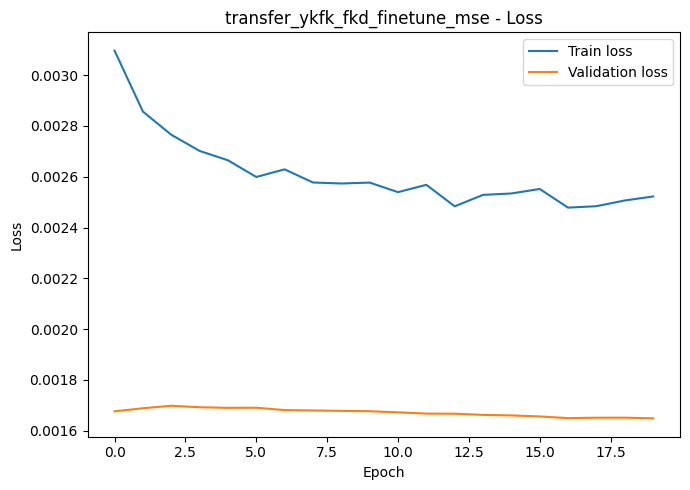

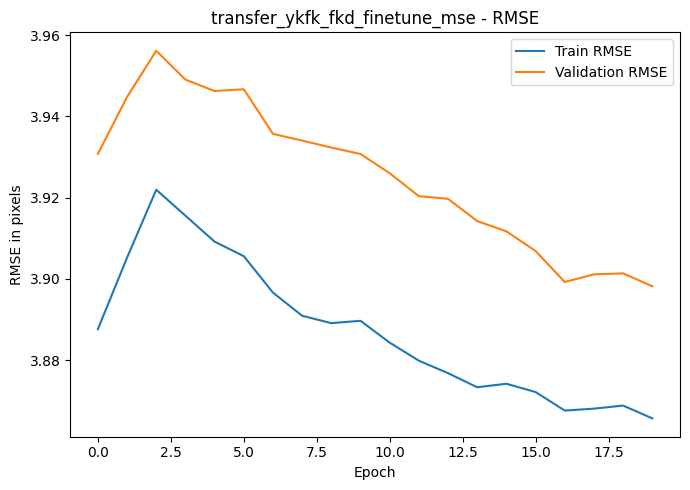

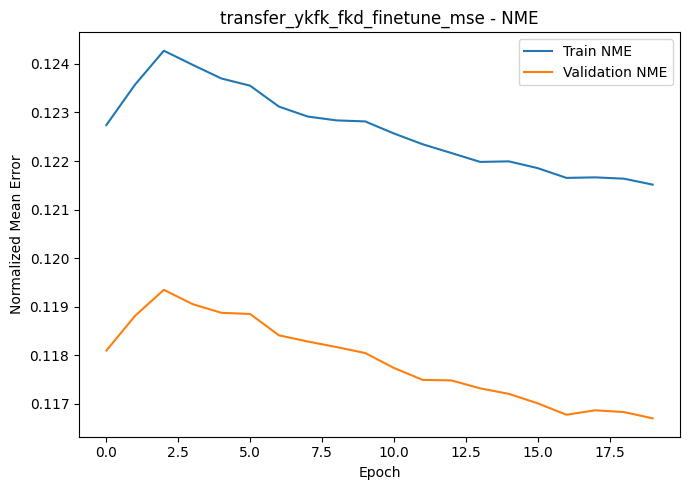

Transfer fine-tuning completed.


In [ ]:
# Fine-tune the last pretrained layers with a lower learning rate

transfer_finetune_config = {
    "experiment_name": "transfer_ykfk_fkd_finetune_mse",
    "model_family": "transfer_learning",
    "architecture": "YKFK MobileNetV2 feature extractor partially fine-tuned + FKD dense head",
    "optimizer": "adam",
    "learning_rate": 1e-5,
    "loss": "masked_mse",
    "batch_size": 64,
    "epochs": 20,
    "fine_tune_last_layers": 30
}

feature_extractor.trainable = True

for layer in feature_extractor.layers[:-transfer_finetune_config["fine_tune_last_layers"]]:
    layer.trainable = False

for layer in feature_extractor.layers[-transfer_finetune_config["fine_tune_last_layers"]:]:
    layer.trainable = True

fkd_transfer_model.compile(
    optimizer=Adam(learning_rate=transfer_finetune_config["learning_rate"]),
    loss=masked_mse_keras
)

finetune_metrics_callback = TransferMetricsCallback(
    X_train_transfer,
    y_train_transfer,
    mask_train_transfer,
    X_val_transfer,
    y_val_transfer,
    mask_val_transfer,
    batch_size=transfer_finetune_config["batch_size"]
)

transfer_finetune_history = fkd_transfer_model.fit(
    X_train_transfer,
    y_train_transfer_combined,
    validation_data=(X_val_transfer, y_val_transfer_combined),
    batch_size=transfer_finetune_config["batch_size"],
    epochs=transfer_finetune_config["epochs"],
    callbacks=[finetune_metrics_callback],
    verbose=1
)

transfer_finetune_history_df = build_transfer_history_df(
    transfer_finetune_history,
    finetune_metrics_callback
)

transfer_finetune_history_df.to_csv(
    RESULTS_DIR / f"{transfer_finetune_config['experiment_name']}_history.csv",
    index=False
)

plot_transfer_training_history(
    transfer_finetune_history_df,
    transfer_finetune_config["experiment_name"]
)

fkd_transfer_model.save(
    MODELS_DIR / f"{transfer_finetune_config['experiment_name']}.keras"
)

print("Transfer fine-tuning completed.")

In [ ]:
# Evaluate the fine-tuned transfer-learning model with NME and append results to the global table

val_transfer_predictions = fkd_transfer_model.predict(
    X_val_transfer,
    batch_size=transfer_finetune_config["batch_size"]
)

test_transfer_predictions = fkd_transfer_model.predict(
    X_test_transfer,
    batch_size=transfer_finetune_config["batch_size"]
)

val_transfer_metrics = compute_transfer_metrics_numpy(
    y_true=y_val_transfer,
    y_pred=val_transfer_predictions,
    mask=mask_val_transfer
)

test_transfer_metrics = compute_transfer_metrics_numpy(
    y_true=y_test_transfer,
    y_pred=test_transfer_predictions,
    mask=mask_test_transfer
)

transfer_summary = pd.DataFrame([{
    "model": transfer_finetune_config["model_family"],
    "architecture": transfer_finetune_config["architecture"],
    "optimizer": transfer_finetune_config["optimizer"],
    "loss": transfer_finetune_config["loss"],
    "rmse": val_transfer_metrics["rmse"],
    "mae": val_transfer_metrics["mae"],
    "normalized_mean_error": val_transfer_metrics["nme"],
    "experiment_name": transfer_finetune_config["experiment_name"],
    "test_rmse": test_transfer_metrics["rmse"],
    "test_mae": test_transfer_metrics["mae"],
    "test_normalized_mean_error": test_transfer_metrics["nme"]
}])

transfer_summary.to_csv(
    RESULTS_DIR / f"{transfer_finetune_config['experiment_name']}_summary.csv",
    index=False
)

display(transfer_summary)

append_global_result({
    "model": transfer_finetune_config["model_family"],
    "architecture": transfer_finetune_config["architecture"],
    "optimizer": transfer_finetune_config["optimizer"],
    "loss": transfer_finetune_config["loss"],
    "rmse": val_transfer_metrics["rmse"],
    "mae": val_transfer_metrics["mae"],
    "normalized_mean_error": val_transfer_metrics["nme"],
    "experiment_name": transfer_finetune_config["experiment_name"]
})

print("Validation transfer metrics:", val_transfer_metrics)
print("Test transfer metrics:", test_transfer_metrics)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step


,model,architecture,optimizer,loss,rmse,mae,normalized_mean_error,experiment_name,test_rmse,test_mae,test_normalized_mean_error
0,transfer_learning,YKFK MobileNetV2 feature extractor partially f...,adam,masked_mse,3.898177,2.645292,0.116702,transfer_ykfk_fkd_finetune_mse,3.824378,2.655458,0.119468


,model,architecture,optimizer,loss,rmse,mae,normalized_mean_error,experiment_name
0,mean_keypoint_baseline,constant_mean_prediction,none,none,3.907841,2.648260,0.116925,NaN
1,transfer_learning,YKFK MobileNetV2 feature extractor partially f...,adam,masked_mse,3.898177,2.645292,0.116702,transfer_ykfk_fkd_finetune_mse


Validation transfer metrics: {'rmse': np.float32(3.8981774), 'mae': np.float32(2.6452916), 'nme': np.float32(0.11670164)}
Test transfer metrics: {'rmse': np.float32(3.8243783), 'mae': np.float32(2.6554582), 'nme': np.float32(0.11946765)}


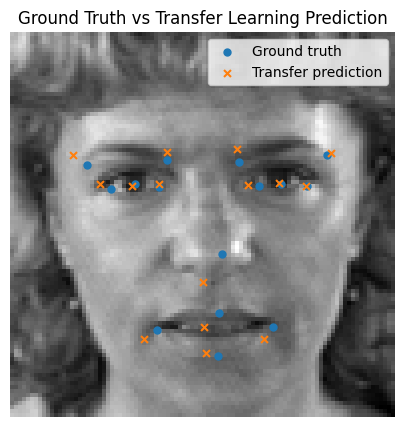

In [ ]:
# Visualize transfer-learning predictions against ground truth keypoints

def plot_transfer_prediction(row, prediction, save_path=None):
    image = image_string_to_array(row["Image"])

    true_keypoints = row[KEYPOINT_COLUMNS].values.astype(np.float32).reshape(-1, 2)
    pred_keypoints = (prediction * 96.0).reshape(-1, 2)

    true_valid = ~np.isnan(true_keypoints).any(axis=1)

    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap="gray")
    plt.scatter(
        true_keypoints[true_valid, 0],
        true_keypoints[true_valid, 1],
        s=25,
        marker="o",
        label="Ground truth"
    )
    plt.scatter(
        pred_keypoints[:, 0],
        pred_keypoints[:, 1],
        s=25,
        marker="x",
        label="Transfer prediction"
    )
    plt.title("Ground Truth vs Transfer Learning Prediction")
    plt.legend()
    plt.axis("off")

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)

    plt.show()


complete_val_indices = val_model_df.index[val_model_df["is_complete"] == 1].tolist()
sample_index = complete_val_indices[0]

plot_transfer_prediction(
    row=val_model_df.loc[sample_index],
    prediction=val_transfer_predictions[sample_index],
    save_path=PLOTS_DIR / "transfer_learning_true_vs_prediction.png"
)